# The Fama–French Five-Factor Model — and Whether It Beats the Three-Factor Model

**A 15-year study on 500+ US equities**

---

## What this notebook does

This is the companion to the three-factor notebook. It repeats the full analysis — theory,
construction, assumptions, residual diagnostics, GRS tests, Fama–MacBeth regressions, rolling
re-estimation and the factor/residual figure — for the Fama–French (2015) **five-factor
model**, which adds profitability (RMW) and investment (CMA) to the original three.

It then does the thing the brief asks for that the first notebook could not: **a direct,
like-for-like adjudication of FF5 versus FF3.** That comparison is built on six independent
pieces of evidence, and they do not all point the same way — which is itself the honest
answer.

| Test | What it asks | Section |
|---|---|---|
| Nested Wald / F-test | Are $\beta^{RMW}$ and $\beta^{CMA}$ jointly zero for individual stocks? | §7.2 |
| Adjusted $R^2$, AIC, BIC | Do the extra factors pay for their degrees of freedom? | §7.3 |
| GRS on five test-asset sets | Does FF5 produce smaller, jointly-insignificant pricing errors? | §8 |
| Alpha heat maps | *Where* in the cross-section does each model fail? | §8.4 |
| Spanning regressions | Is any factor redundant given the others? | §9 |
| Out-of-sample residuals | Does the improvement survive real-time estimation? | §11 |

**Crucial methodological choice.** Both models are built from the *same* published file, so
that FF3 is a strict subset of FF5. Without this, the nested tests are invalid — see §3.

**Runtime.** First run downloads ~900 tickers of daily data (4–10 minutes) and caches
everything to `./data_cache`, which is shared with the three-factor notebook. If you have
already run that notebook, the data step here is instant.

---
# 1. Setup

In [1]:
# ============================================================================
#  0.1  Environment bootstrap
# ----------------------------------------------------------------------------
#  Set AUTO_INSTALL = False if you prefer to manage your own environment.
#  Manual equivalent:
#      pip install numpy pandas scipy matplotlib statsmodels yfinance requests lxml
# ============================================================================
AUTO_INSTALL = True

import importlib.util, subprocess, sys

REQUIRED = {          # import-name -> pip-name
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "matplotlib": "matplotlib", "statsmodels": "statsmodels",
    "yfinance": "yfinance", "requests": "requests", "lxml": "lxml",
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]

if missing:
    if AUTO_INSTALL:
        print("Installing missing packages:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
        print("Done.")
    else:
        raise ImportError("Missing packages: " + ", ".join(missing))
else:
    print("All required packages already present.")

All required packages already present.


In [2]:
# ============================================================================
#  0.2  Imports, global configuration and plotting style
# ============================================================================
import io, os, sys, time, zipfile, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import scipy.stats as st
from scipy.stats import f as f_dist

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import (acorr_ljungbox, het_breuschpagan,
                                          het_white, het_arch, acorr_breusch_godfrey)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

import yfinance as yf
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.random.seed(42)

# ---- pandas version compatibility (month-end alias changed in pandas 2.2) ---
def _month_end_alias():
    for alias in ("ME", "M"):
        try:
            pd.tseries.frequencies.to_offset(alias)
            return alias
        except Exception:
            continue
    return "M"

ME = _month_end_alias()


def month_end_index(idx):
    """Normalise any date-like index to unambiguous month-end midnight stamps,
    so Yahoo months and Ken French months line up exactly."""
    p = idx if isinstance(idx, pd.PeriodIndex) else pd.DatetimeIndex(idx).to_period("M")
    return p.to_timestamp(how="end").normalize()

# ---------------------------------------------------------------- config ---
CFG = dict(
    EVAL_YEARS        = 15,    # length of the evaluation window requested
    BURN_IN_YEARS     = 7,     # 5y for the first rolling window + 2y so that an
                               # annual (June) portfolio formation date always exists
    EST_WINDOW        = 60,    # months in each rolling estimation window
    MIN_OBS_IN_WINDOW = 48,    # min non-missing months to accept a window
    N_QUANTILES       = 5,     # 5x5 = 25 test portfolios
    MIN_STOCK_MONTHS  = 120,   # min monthly observations to keep a stock
    TARGET_UNIVERSE   = 500,   # hard requirement from the brief
)

CACHE = Path("./data_cache"); CACHE.mkdir(exist_ok=True)
FIGDIR = Path("./figures");   FIGDIR.mkdir(exist_ok=True)

# End of sample = last complete calendar month.
_today   = pd.Timestamp.today().normalize()
END_DATE = (_today.replace(day=1) - pd.Timedelta(days=1))
EVAL_START = (END_DATE - pd.DateOffset(years=CFG["EVAL_YEARS"])).replace(day=1)
DATA_START = (EVAL_START - pd.DateOffset(years=CFG["BURN_IN_YEARS"])).replace(day=1)

print(f"Download window : {DATA_START:%Y-%m-%d}  ->  {END_DATE:%Y-%m-%d}"
      f"   ({CFG['EVAL_YEARS'] + CFG['BURN_IN_YEARS']} years)")
print(f"Evaluation window: {EVAL_START:%Y-%m-%d}  ->  {END_DATE:%Y-%m-%d}"
      f"   ({CFG['EVAL_YEARS']} years, as requested)")
print(f"The first {CFG['BURN_IN_YEARS']} years are burn-in: they are consumed by the "
      f"{CFG['EST_WINDOW']}-month rolling window so that\nevery month of the 15-year "
      f"evaluation window has a genuine out-of-sample beta estimate.")

# ---------------------------------------------------------------- styling --
mpl.rcParams.update({
    "figure.figsize": (13, 5.5), "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "axes.labelsize": 10.5,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "font.family": "DejaVu Sans",
})

PALETTE = {
    "Mkt-RF": "#1f3b73", "SMB": "#c1440e", "HML": "#2a7f62",
    "RMW":    "#7b3f9d", "CMA": "#b58900", "MOM": "#4f4f4f", "RF": "#8a8a8a",
}
PCT = FuncFormatter(lambda v, _: f"{v:,.0%}")
print("\nSetup complete.")

Download window : 2004-07-01  ->  2026-07-31   (22 years)
Evaluation window: 2011-07-01  ->  2026-07-31   (15 years, as requested)
The first 7 years are burn-in: they are consumed by the 60-month rolling window so that
every month of the 15-year evaluation window has a genuine out-of-sample beta estimate.

Setup complete.


In [3]:
# ============================================================================
#  0.3  Econometrics toolkit
#  Everything statistical used later in the notebook is defined here once, so
#  the analysis cells stay readable and every test is applied consistently.
# ============================================================================

# ---------------------------------------------------------------------------
#  Newey-West lag rule of thumb, Newey & West (1994):  L = floor(4*(T/100)^(2/9))
# ---------------------------------------------------------------------------
def nw_lags(T: int) -> int:
    return int(max(1, np.floor(4.0 * (T / 100.0) ** (2.0 / 9.0))))


def ols(y, X, hac: bool = True, lags: int | None = None):
    """OLS of y on X (constant added automatically). Returns a fitted
    statsmodels result. HAC = Newey-West heteroskedasticity- and
    autocorrelation-consistent covariance (the default for return regressions)."""
    y = pd.Series(y).astype(float)
    X = pd.DataFrame(X).astype(float)
    X = sm.add_constant(X, has_constant="add")
    idx = y.index.intersection(X.index)
    y, X = y.loc[idx], X.loc[idx]
    ok = y.notna() & X.notna().all(axis=1)
    y, X = y[ok], X[ok]
    model = sm.OLS(y, X)
    if hac:
        L = lags if lags is not None else nw_lags(len(y))
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": L, "use_correction": True})
    return model.fit()


def nw_mean_tstat(s):
    """Mean of a series with a Newey-West standard error and t-statistic.
    (Regressing the series on a constant with HAC errors.)"""
    s = pd.Series(s).dropna().astype(float)
    if len(s) < 6:
        return float(s.mean()), np.nan, np.nan
    X = np.ones((len(s), 1))
    r = sm.OLS(s.to_numpy(), X).fit(cov_type="HAC",
                                    cov_kwds={"maxlags": nw_lags(len(s)),
                                              "use_correction": True})
    return float(r.params[0]), float(r.bse[0]), float(r.tvalues[0])


def ann_stats(r: pd.Series, freq: int = 12) -> dict:
    """Standard annualised description of a monthly return series."""
    r = pd.Series(r).dropna()
    T = len(r)
    mu, sd = r.mean(), r.std(ddof=1)
    _, se_nw, _ = nw_mean_tstat(r)
    cum = (1 + r).cumprod()
    dd = (cum / cum.cummax() - 1).min()
    return {
        "N (months)":  T,
        "Mean (%/mo)": 100 * mu,
        "t-stat (NW)": (mu / se_nw) if (se_nw and np.isfinite(se_nw)) else np.nan,
        "Ann. return": (1 + mu) ** freq - 1,
        "Ann. vol":    sd * np.sqrt(freq),
        "Sharpe":      (mu / sd) * np.sqrt(freq) if sd > 0 else np.nan,
        "Skew":        st.skew(r, bias=False),
        "Ex. kurt":    st.kurtosis(r, bias=False),
        "Max DD":      dd,
    }


# ---------------------------------------------------------------------------
#  Gibbons, Ross & Shanken (1989) test.
#
#      GRS = ((T-N-K)/N) * [ a' S^-1 a ] / [ 1 + m' W^-1 m ]  ~  F(N, T-N-K)
#
#  a = N-vector of regression intercepts, S = MLE residual covariance,
#  m = mean factor returns, W = MLE factor covariance.
#  H0: all N intercepts are jointly zero, i.e. the factors price the test
#  assets exactly. This is *the* formal test of a linear factor model.
# ---------------------------------------------------------------------------
def grs_test(R: pd.DataFrame, F: pd.DataFrame) -> dict:
    R = pd.DataFrame(R).dropna(how="any")
    F = pd.DataFrame(F)
    idx = R.index.intersection(F.index)
    R, F = R.loc[idx].to_numpy(float), F.loc[idx].to_numpy(float)
    T, N = R.shape
    K = F.shape[1]
    if T - N - K <= 0:
        return {"GRS F": np.nan, "p-value": np.nan, "N": N, "T": T,
                "mean |alpha| (%/mo)": np.nan, "mean |t(alpha)|": np.nan,
                "SR(alpha)": np.nan, "SR(factors)": np.nan, "share |t|>1.96": np.nan,
                "note": "T - N - K <= 0, GRS not computable"}

    X = np.column_stack([np.ones(T), F])
    B = np.linalg.lstsq(X, R, rcond=None)[0]          # (K+1) x N
    a = B[0]
    E = R - X @ B                                      # T x N residuals
    S = E.T @ E / T                                    # MLE residual covariance
    m = F.mean(axis=0)
    W = np.cov(F, rowvar=False, bias=True).reshape(K, K)

    S_inv, W_inv = np.linalg.pinv(S), np.linalg.pinv(W)
    a2  = float(a @ S_inv @ a)                         # squared SR of pricing errors
    sr2 = float(m @ W_inv @ m)                         # squared SR of the factors
    stat = (T - N - K) / N * a2 / (1.0 + sr2)
    pval = float(f_dist.sf(stat, N, T - N - K))

    # individual alpha t-stats with Newey-West standard errors
    tstats = []
    XtXi = np.linalg.pinv(X.T @ X)
    L = nw_lags(T)
    for j in range(N):
        e = E[:, j]
        Sw = (e[:, None] * X).T @ (e[:, None] * X)
        for l in range(1, L + 1):
            u, v = (e[l:, None] * X[l:]), (e[:-l, None] * X[:-l])
            G = u.T @ v
            Sw += (1 - l / (L + 1)) * (G + G.T)
        V = XtXi @ Sw @ XtXi
        tstats.append(a[j] / np.sqrt(max(V[0, 0], 1e-18)))
    tstats = np.asarray(tstats)

    return {
        "GRS F": stat, "p-value": pval, "N": N, "T": T,
        "mean |alpha| (%/mo)": 100 * np.mean(np.abs(a)),
        "mean |t(alpha)|": np.mean(np.abs(tstats)),
        "SR(alpha)": np.sqrt(max(a2, 0)),
        "SR(factors)": np.sqrt(max(sr2, 0)),
        "share |t|>1.96": float(np.mean(np.abs(tstats) > 1.96)),
    }


# ---------------------------------------------------------------------------
#  Full residual diagnostic battery for a single time-series regression.
# ---------------------------------------------------------------------------
def residual_diagnostics(res, lb_lags: int = 12) -> pd.DataFrame:
    e = np.asarray(res.resid, float)
    X = np.asarray(res.model.exog, float)
    T = len(e)
    rows = []

    jb, jb_p, skew, kurt = jarque_bera(e)
    rows.append(("Normality", "Jarque-Bera", jb, jb_p,
                 "residuals are Normal"))

    lb = acorr_ljungbox(e, lags=[lb_lags], return_df=True)
    rows.append(("Autocorrelation", f"Ljung-Box(Q{lb_lags})",
                 float(lb["lb_stat"].iloc[0]), float(lb["lb_pvalue"].iloc[0]),
                 "no autocorrelation up to lag %d" % lb_lags))

    try:
        bg = acorr_breusch_godfrey(res, nlags=min(6, T // 10))
        rows.append(("Autocorrelation", "Breusch-Godfrey(6)", bg[0], bg[1],
                     "no serial correlation"))
    except Exception:
        pass

    bp = het_breuschpagan(e, X)
    rows.append(("Heteroskedasticity", "Breusch-Pagan", bp[0], bp[1],
                 "homoskedastic residuals"))
    try:
        wh = het_white(e, X)
        rows.append(("Heteroskedasticity", "White", wh[0], wh[1],
                     "homoskedastic residuals"))
    except Exception:
        pass

    ar = het_arch(e, nlags=min(12, T // 10))
    rows.append(("Volatility clustering", "Engle ARCH-LM(12)", ar[0], ar[1],
                 "no ARCH effects"))

    dw = durbin_watson(e)
    rows.append(("Autocorrelation", "Durbin-Watson", dw, np.nan,
                 "~2.0 means no first-order autocorrelation"))

    out = pd.DataFrame(rows, columns=["Assumption", "Test", "Statistic",
                                      "p-value", "Null hypothesis (H0)"])
    out["Reject H0 @5%"] = np.where(out["p-value"].notna(),
                                    np.where(out["p-value"] < 0.05, "YES", "no"), "-")
    return out


def vif_table(X: pd.DataFrame) -> pd.DataFrame:
    """Variance-inflation factors. VIF > 5 (some say 10) flags multicollinearity."""
    Xc = sm.add_constant(pd.DataFrame(X).dropna(), has_constant="add")
    vals = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
    out = pd.DataFrame({"VIF": vals}, index=Xc.columns).drop(index="const")
    out["Interpretation"] = np.where(out["VIF"] > 10, "severe",
                             np.where(out["VIF"] > 5, "moderate", "benign"))
    return out


# ---------------------------------------------------------------------------
#  Panel regression engine: identical regressors for every stock, so we can
#  solve all stocks at once with a single least-squares call per window.
# ---------------------------------------------------------------------------
def batch_ols(Y: pd.DataFrame, F: pd.DataFrame):
    """Full-sample OLS of every column of Y on F. Returns (params, tstats,
    r2, adj_r2, residuals). Uses Newey-West t-stats for the intercept and
    slopes. Stocks are handled column-by-column but with shared design work."""
    idx = Y.index.intersection(F.index)
    Y, F = Y.loc[idx], F.loc[idx]
    names = ["alpha"] + list(F.columns)
    params, tstats, r2s, ar2s, nobs, resid = {}, {}, {}, {}, {}, {}
    for c in Y.columns:
        y = Y[c].dropna()
        if len(y) < 36:
            continue
        r = ols(y, F.loc[y.index])
        params[c] = r.params.values
        tstats[c] = r.tvalues.values
        r2s[c], ar2s[c], nobs[c] = r.rsquared, r.rsquared_adj, int(r.nobs)
        resid[c] = pd.Series(r.resid, index=y.index)
    P = pd.DataFrame(params, index=names).T
    Tt = pd.DataFrame(tstats, index=[f"t_{n}" for n in names]).T
    out = P.join(Tt)
    out["R2"] = pd.Series(r2s)
    out["adj_R2"] = pd.Series(ar2s)
    out["nobs"] = pd.Series(nobs)
    return out, pd.DataFrame(resid)


def rolling_betas_and_oos_resid(Y: pd.DataFrame, F: pd.DataFrame,
                                window: int, min_obs: int):
    """Rolling-window estimation, updated every month.

    For each month t we estimate betas on months [t-window, t-1] and then
    compute the *out-of-sample* residual for month t:

        e_t = r_t - ( alpha_hat + beta_hat' f_t )

    Because all stocks share the same regressors within a window, each window
    is one multi-response least-squares solve, which makes this fast even for
    600+ stocks x 180+ months.

    Returns
    -------
    betas   : dict of DataFrames (one per coefficient), index = month t
    oos_res : DataFrame of one-step-ahead residuals, index = month t
    r2_is   : DataFrame of in-window R^2
    """
    idx = Y.index.intersection(F.index)
    Y, F = Y.loc[idx], F.loc[idx]
    names = ["alpha"] + list(F.columns)
    Fv = np.column_stack([np.ones(len(F)), F.to_numpy(float)])
    Yv = Y.to_numpy(float)
    T, M = Yv.shape

    beta_store = {n: np.full((T, M), np.nan) for n in names}
    oos = np.full((T, M), np.nan)
    r2  = np.full((T, M), np.nan)

    for t in range(window, T):
        Xw, Yw = Fv[t - window:t], Yv[t - window:t]
        good = np.isfinite(Yw).sum(axis=0) >= min_obs
        if not good.any():
            continue
        cols = np.where(good)[0]
        Yg = Yw[:, cols]
        full = np.isfinite(Yg).all(axis=1)
        if full.sum() >= min_obs:
            # fast path: one solve for the stocks with complete windows
            B = np.linalg.lstsq(Xw[full], Yg[full], rcond=None)[0]
            fitted = Xw[full] @ B
            ss_res = np.nansum((Yg[full] - fitted) ** 2, axis=0)
            ss_tot = np.nansum((Yg[full] - Yg[full].mean(0)) ** 2, axis=0)
        else:
            B = np.full((Fv.shape[1], len(cols)), np.nan)
            ss_res = ss_tot = np.full(len(cols), np.nan)
        # stocks with gaps: solve individually
        gaps = np.where(~np.isfinite(Yg).all(axis=0))[0]
        for j in gaps:
            m = np.isfinite(Yg[:, j])
            if m.sum() < min_obs:
                B[:, j] = np.nan
                continue
            b = np.linalg.lstsq(Xw[m], Yg[m, j], rcond=None)[0]
            B[:, j] = b
            fit = Xw[m] @ b
            ss_res[j] = np.sum((Yg[m, j] - fit) ** 2)
            ss_tot[j] = np.sum((Yg[m, j] - Yg[m, j].mean()) ** 2)

        for i, n in enumerate(names):
            beta_store[n][t, cols] = B[i]
        with np.errstate(invalid="ignore", divide="ignore"):
            r2[t, cols] = 1 - ss_res / ss_tot
        oos[t, cols] = Yv[t, cols] - Fv[t] @ B

    betas = {n: pd.DataFrame(v, index=Y.index, columns=Y.columns)
             for n, v in beta_store.items()}
    return (betas,
            pd.DataFrame(oos, index=Y.index, columns=Y.columns),
            pd.DataFrame(r2,  index=Y.index, columns=Y.columns))


def fama_macbeth(R: pd.DataFrame, betas: dict, factor_names) -> pd.DataFrame:
    """Fama & MacBeth (1973) two-pass cross-sectional regression.

    Pass 1 (already done): rolling betas.
    Pass 2: each month, regress the cross-section of realised excess returns on
    last month's betas. Report the time-series mean of the slopes with
    Newey-West t-statistics. Under the model the slope on beta_k should equal
    the average return of factor k."""
    cols = [f"beta_{n}" for n in factor_names]
    gammas = []
    for t in R.index:
        y = R.loc[t]
        Xrow = pd.DataFrame({f"beta_{n}": betas[n].loc[t] for n in factor_names})
        d = pd.concat([y.rename("r"), Xrow], axis=1).dropna()
        if len(d) < 30:
            continue
        fit = sm.OLS(d["r"], sm.add_constant(d[cols])).fit()
        gammas.append(pd.Series(fit.params.values,
                                index=["gamma_0"] + cols, name=t))
    G = pd.DataFrame(gammas)
    rows = {}
    for c in G.columns:
        s = G[c].dropna()
        mu_g, se_g, t_g = nw_mean_tstat(s)
        rows[c] = {"Mean (%/mo)": 100 * s.mean(),
                   "Std (%/mo)": 100 * s.std(),
                   "t-stat (NW)": t_g,
                   "p-value": 2 * (1 - st.norm.cdf(abs(t_g))),
                   "Ann. premium": (1 + s.mean()) ** 12 - 1,
                   "N months": len(s)}
    return pd.DataFrame(rows).T, G


def show(df, caption=None, fmt="{:,.3f}"):
    """Pretty-print a DataFrame in a notebook."""
    try:
        from IPython.display import display
        sty = df.style.format(fmt, na_rep="-")
        if caption:
            sty = sty.set_caption(caption)
        display(sty)
    except Exception:
        if caption:
            print(caption)
        print(df)

print("Econometrics toolkit loaded:",
      "nw_lags, ols, ann_stats, grs_test, residual_diagnostics, vif_table,",
      "batch_ols, rolling_betas_and_oos_resid, fama_macbeth, nw_mean_tstat, show")

Econometrics toolkit loaded: nw_lags, ols, ann_stats, grs_test, residual_diagnostics, vif_table, batch_ols, rolling_betas_and_oos_resid, fama_macbeth, nw_mean_tstat, show


In [4]:
# ============================================================================
#  2.1  Test-portfolio machinery
#  A factor model is not judged on how well it fits the assets it was built
#  from - it is judged on whether it prices assets it has never seen. So we
#  need TEST ASSETS with wide dispersion in average returns. We use three sets:
#
#   Set A  Ken French's 25 Size x Book-to-Market portfolios.  Bias-free,
#          point-in-time correct, and the canonical test assets of the
#          entire literature. Nothing we compute contaminates them.
#   Set B  25 portfolios from OUR OWN 500+ stocks, double-sorted on
#          pre-ranking SMB-beta and HML-beta (Fama-MacBeth 1973 style).
#          Uses only returns, so no fundamentals or look-ahead are required.
#   Set C  25 portfolios double-sorted on a size proxy and 12-2 momentum.
#          These are the assets the model is known to FAIL on - included on
#          purpose, because a fair test has to include the hard cases.
# ============================================================================

def quintile_codes(sig: pd.DataFrame, n_q: int) -> pd.DataFrame:
    """Cross-sectional quintile (1..n_q) of a signal, computed row by row."""
    pct = sig.rank(axis=1, pct=True, method="first")
    return np.ceil(pct * n_q).clip(lower=1, upper=n_q)


def sorted_portfolios(sig_a: pd.DataFrame, sig_b: pd.DataFrame, EXR: pd.DataFrame,
                      n_q: int = 5, min_names: int = 5,
                      tags=("A", "B")) -> pd.DataFrame:
    """Independent double sort into n_q x n_q equal-weighted portfolios.

    Signals are dated at the FORMATION month t and are built only from
    information available at t; returns are taken in month t+1 (the .shift(1)
    below). That one line is what keeps the exercise free of look-ahead bias.
    """
    qa = quintile_codes(sig_a.reindex_like(EXR), n_q)
    qb = quintile_codes(sig_b.reindex_like(EXR), n_q)
    codes = (qa * 100 + qb).shift(1)          # formed at t, held at t+1
    out = {}
    for a in range(1, n_q + 1):
        for b in range(1, n_q + 1):
            m = codes == (a * 100 + b)
            n = m.sum(axis=1)
            s = EXR.where(m).mean(axis=1)
            out[f"{tags[0]}{a}{tags[1]}{b}"] = s.where(n >= min_names)
    P = pd.DataFrame(out)
    return P


def annual_signal(df: pd.DataFrame, month: int = 6) -> pd.DataFrame:
    """Freeze a signal at one month per year and hold it for twelve months.
    This is the Fama-French rebalancing convention (end of June)."""
    s = df.copy()
    keep = df.index.month == month
    any_data = df.notna().any(axis=1)
    if any_data.any():                       # also seed on the first usable row,
        keep = keep | (df.index == any_data.idxmax())   # so no year is lost
    s[~keep] = np.nan
    return s.ffill()


def momentum_12_2(R: pd.DataFrame) -> pd.DataFrame:
    """Jegadeesh-Titman 12-2 momentum: compound return over months t-11..t-1,
    skipping the most recent month to sidestep short-term reversal."""
    lg = np.log1p(R)
    return np.expm1(lg.rolling(11, min_periods=8).sum().shift(1))


def portfolio_spread_table(P: pd.DataFrame, label: str) -> pd.DataFrame:
    """Mean excess return of each test portfolio - the dispersion the model
    has to explain. A flat table would make the test vacuous."""
    m = P.mean() * 12
    return pd.DataFrame({f"{label}: ann. mean excess return": m}).T


def model_comparison(P: pd.DataFrame, FF: pd.DataFrame,
                     specs: dict, sample_mask=None) -> pd.DataFrame:
    """Run the GRS test for several competing factor specifications on the
    same set of test assets, and stack the results into one table."""
    rows = {}
    for name, cols in specs.items():
        Fm = FF[cols]
        Pm = P if sample_mask is None else P.loc[sample_mask]
        Fm = Fm.reindex(Pm.index)
        rows[name] = grs_test(Pm.dropna(axis=1, how="any"), Fm)
    T = pd.DataFrame(rows).T
    T = T[["GRS F", "p-value", "mean |alpha| (%/mo)", "mean |t(alpha)|",
           "share |t|>1.96", "SR(alpha)", "SR(factors)", "N", "T"]]
    return T


def cross_sectional_fit(P: pd.DataFrame, FF: pd.DataFrame, cols) -> tuple:
    """Realised vs model-predicted average excess return for each test asset.
    predicted_i = beta_i' * mean(factors);  realised_i = mean(r_i).
    Returns (dataframe, cross-sectional R^2). This is the picture that makes
    'does the model work?' visible rather than merely testable."""
    Fm = FF[cols].reindex(P.index)
    d = pd.concat([P, Fm], axis=1).dropna()
    Y, X = d[P.columns], sm.add_constant(d[cols])
    B = np.linalg.lstsq(X.values, Y.values, rcond=None)[0]
    betas = B[1:, :].T                                    # N x K
    pred = betas @ Fm.loc[d.index].mean().values
    real = Y.mean().values
    ss_res = np.sum((real - pred) ** 2)
    ss_tot = np.sum((real - real.mean()) ** 2)
    return (pd.DataFrame({"realised": real, "predicted": pred}, index=P.columns),
            1 - ss_res / ss_tot)


print("Portfolio toolkit loaded.")

Portfolio toolkit loaded.


In [5]:
# ============================================================================
#  2.2  Plotting helpers
# ============================================================================
def shade_drawdowns(ax, mkt: pd.Series, threshold: float = 0.10, label_first=True):
    """Shade every period in which the market is more than `threshold` below
    its running peak. Purely data-driven, so it adapts to any sample."""
    cum = (1 + mkt).cumprod()
    dd = cum / cum.cummax() - 1
    inside = dd < -threshold
    start = None
    first = True
    for t, flag in inside.items():
        if flag and start is None:
            start = t
        elif not flag and start is not None:
            ax.axvspan(start, t, color="#c0392b", alpha=0.07,
                       label=f"market >{threshold:.0%} below peak"
                             if (first and label_first) else None)
            start, first = None, False
    if start is not None:
        ax.axvspan(start, inside.index[-1], color="#c0392b", alpha=0.07,
                   label=f"market >{threshold:.0%} below peak"
                         if (first and label_first) else None)


def plot_factor_cumulative(ax, FF: pd.DataFrame, cols, start=None, log=True):
    sub = FF[cols] if start is None else FF.loc[FF.index >= start, cols]
    for c in cols:
        growth = (1 + sub[c]).cumprod()
        ax.plot(growth.index, growth.values, lw=1.9,
                color=PALETTE.get(c, None), label=c)
    ax.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.5)
    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.1f}x"))
    return sub


def diagnostic_panel(res, title: str, figsize=(14, 9)):
    """The classic four-way residual diagnostic display."""
    e = res.resid if isinstance(res.resid, pd.Series) else pd.Series(res.resid)
    fitted = pd.Series(np.asarray(res.fittedvalues, float), index=e.index)

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title, fontsize=13.5, fontweight="bold", y=0.98)

    ax = axes[0, 0]
    ax.scatter(fitted, e, s=13, alpha=0.55, color="#1f3b73", edgecolor="none")
    ax.axhline(0, color="k", lw=0.9)
    lo = sm.nonparametric.lowess(e.values, fitted.values, frac=0.5, return_sorted=True)
    ax.plot(lo[:, 0], lo[:, 1], color="#c1440e", lw=2)
    ax.set(xlabel="Fitted value", ylabel="Residual",
           title="Residuals vs fitted\n(flat red line => linearity holds)")

    ax = axes[0, 1]
    st.probplot(e.values, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=3.5, color="#1f3b73", alpha=0.65)
    ax.get_lines()[1].set(color="#c1440e", lw=2)
    ax.set_title("Normal Q-Q plot\n(tails off the line => fat tails)")

    ax = axes[1, 0]
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(e.values, lags=min(24, max(4, len(e) // 4)), ax=ax, alpha=0.05)
    ax.set(title="Residual autocorrelation\n(bars inside the band => no serial correlation)",
           xlabel="Lag (months)")

    ax = axes[1, 1]
    ax.plot(e.index, e.rolling(12).std() * np.sqrt(12), lw=1.8, color="#2a7f62")
    ax.axhline(e.std() * np.sqrt(12), color="#c1440e", ls="--", lw=1.4,
               label="full-sample")
    ax.set(title="Rolling 12-month residual volatility\n(swings => heteroskedasticity / ARCH)",
           ylabel="Annualised idiosyncratic vol")
    ax.yaxis.set_major_formatter(PCT)
    ax.legend()

    plt.tight_layout(rect=(0, 0, 1, 0.955))
    return fig


def dual_panel_figure(FF, factor_cols, oos_resid, roll_r2, eval_start,
                      title, fname):
    """THE deliverable figure requested in the brief:
         top    - historical returns of every factor
         bottom - how the model's residuals behave through time
    """
    mask   = oos_resid.index >= eval_start
    res_ev = oos_resid.loc[mask]
    r2_ev  = roll_r2.loc[mask]

    mae   = res_ev.abs().mean(axis=1)                 # cross-sectional MAE
    p10   = res_ev.abs().quantile(0.10, axis=1)
    p90   = res_ev.abs().quantile(0.90, axis=1)
    disp  = res_ev.std(axis=1)                        # cross-sectional dispersion
    r2m   = r2_ev.mean(axis=1)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14.5, 10.5), sharex=True,
        gridspec_kw={"height_ratios": [1.15, 1.0], "hspace": 0.13})

    # ---------------- top: factor returns ----------------------------------
    sub = plot_factor_cumulative(ax1, FF, factor_cols, start=eval_start, log=True)
    shade_drawdowns(ax1, FF.loc[FF.index >= eval_start, "Mkt-RF"])
    ax1.set_title(f"{title}\nPanel A - cumulative total return of each factor "
                  f"({sub.index.min():%b %Y} = 1.00, log scale)", loc="left")
    ax1.set_ylabel("Growth of $1")
    ax1.legend(ncol=len(factor_cols) + 1, loc="upper left", fontsize=10)

    tbl = "\n".join(
        f"{c:<7} {(1+sub[c]).prod()**(12/len(sub))-1:>7.2%} p.a.   "
        f"SR {sub[c].mean()/sub[c].std()*np.sqrt(12):>5.2f}"
        for c in factor_cols)
    ax1.text(0.995, 0.03, tbl, transform=ax1.transAxes, ha="right", va="bottom",
             family="monospace", fontsize=9,
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cccccc", alpha=0.9))

    # ---------------- bottom: residual behaviour ---------------------------
    ax2.fill_between(mae.index, p10, p90, color="#1f3b73", alpha=0.16,
                     label="10th-90th pct of |residual| across stocks")
    ax2.plot(mae.index, mae, lw=1.9, color="#1f3b73",
             label="cross-sectional mean |out-of-sample residual|")
    ax2.plot(disp.index, disp, lw=1.4, color="#c1440e", ls="-",
             label="cross-sectional std of residuals")
    ax2.axhline(mae.mean(), color="#555555", ls=":", lw=1.4,
                label=f"average = {mae.mean():.2%}/month")
    shade_drawdowns(ax2, FF.loc[FF.index >= eval_start, "Mkt-RF"], label_first=False)
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.1%}"))
    ax2.set_ylabel("Monthly residual magnitude")
    ax2.set_xlabel("")

    ax2b = ax2.twinx()
    ax2b.plot(r2m.index, r2m, lw=1.6, color="#2a7f62", alpha=0.85,
              label="mean in-window $R^2$ (right axis)")
    ax2b.set_ylabel("Mean regression $R^2$", color="#2a7f62")
    ax2b.tick_params(axis="y", colors="#2a7f62")
    ax2b.grid(False); ax2b.set_ylim(0, 1)

    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper left", ncol=2, fontsize=9.5)
    ax2.set_title("Panel B - behaviour of the residuals: pricing errors are "
                  "small and mean-reverting in calm markets and spike in crises",
                  loc="left")

    plt.savefig(FIGDIR / fname, bbox_inches="tight")
    plt.show()
    return dict(mae=mae, disp=disp, r2=r2m)

print("Plotting helpers loaded.")

Plotting helpers loaded.


---
# 2. Why add two more factors?

## 2.1 The problem with the three-factor model

By the 2010s, two well-replicated patterns were sitting squarely outside the three-factor
model's reach:

* **Profitability.** Novy-Marx (2013) showed that firms with high gross profitability earn
  substantially higher average returns than firms with low profitability, *with the same*
  book-to-market. This is not a value effect in disguise — in fact profitability and value
  are negatively correlated, so the two strategies hedge one another.
* **Investment.** Titman, Wei and Xie (2004) and Cooper, Gulen and Schill (2008) showed that
  firms that expand their assets aggressively subsequently *underperform* conservative firms.

Fama and French (2015) confirmed that FF3 leaves large, systematic alphas on portfolios sorted
on these two characteristics. That is a specification failure, not noise.

## 2.2 The theoretical argument — and it is a real one

What makes the five-factor model more than curve-fitting is that profitability and investment
fall out of the **dividend discount model** under clean-surplus accounting. This derivation,
due to Miller and Modigliani (1961) and applied here following Fama–French (2015) and
Aharoni, Grundy and Zeng (2013), is worth writing down because it is the whole justification.

Start with the market value of equity as the present value of expected dividends:

$$
M_t \;=\; \sum_{\tau=1}^{\infty} \frac{E[D_{t+\tau}]}{(1+r)^{\tau}}
$$

Under clean surplus accounting, dividends equal earnings minus the change in book equity,
$D_{t+\tau} = Y_{t+\tau} - (B_{t+\tau} - B_{t+\tau-1})$. Substituting and dividing both sides
by book equity $B_t$:

$$
\boxed{\;
\frac{M_t}{B_t}
\;=\;
\frac{\sum_{\tau=1}^{\infty} E\bigl[\,Y_{t+\tau}-\Delta B_{t+\tau}\,\bigr]/(1+r)^{\tau}}{B_t}
\;}
$$

Now read this identity as a set of *ceteris paribus* statements about the internal rate of
return $r$ — which is the expected stock return:

| Hold fixed | Vary | Implication for expected return $r$ |
|---|---|---|
| expected earnings $Y$, expected growth in book $\Delta B$ | **lower** $M_t/B_t$ (i.e. higher B/M) | **higher** $r$ → **the value effect (HML)** |
| $M_t/B_t$, expected $\Delta B$ | **higher** expected earnings $Y$ | **higher** $r$ → **the profitability effect (RMW)** |
| $M_t/B_t$, expected earnings $Y$ | **higher** expected growth in book $\Delta B$ | **lower** $r$ → **the investment effect (CMA)** |

So all three of value, profitability and investment are implications of a single accounting
identity plus the definition of an internal rate of return. **This is the key intellectual
difference from the 1993 paper**, which offered no comparable derivation: FF3's factors were
chosen because they worked empirically, whereas RMW and CMA were chosen because valuation
theory says they *must* matter, and then confirmed empirically.

Note carefully what the identity does *not* say. It is a statement about *expected* earnings
and *expected* investment; realised accounting profitability and asset growth are only proxies.
And it says nothing about whether $r$ is a risk premium or a mispricing — it is silent on the
economics. It only says these three variables belong in the pricing equation.

## 2.3 The five-factor model

$$
\boxed{\;
R_{i,t}-R_{f,t}=\alpha_i
+\beta_i^{MKT}\mathrm{MKT}_t
+\beta_i^{SMB}\mathrm{SMB}_t
+\beta_i^{HML}\mathrm{HML}_t
+\beta_i^{RMW}\mathrm{RMW}_t
+\beta_i^{CMA}\mathrm{CMA}_t
+\varepsilon_{i,t}\;}
$$

| Factor | Full name | Construction (2×3 sorts, rebalanced each June) |
|---|---|---|
| **RMW** | Robust Minus Weak | Average return on the two *robust*-profitability portfolios minus the two *weak* ones. Operating profitability = (revenues − COGS − SG&A − interest) / book equity |
| **CMA** | Conservative Minus Aggressive | Average return on the two *conservative*-investment portfolios minus the two *aggressive* ones. Investment = growth in total assets over the prior fiscal year |

Both are built exactly like HML: a 2×3 independent sort on size and the characteristic, with
NYSE breakpoints, giving six value-weighted portfolios and a zero-net-investment long/short
return. In the five-factor file, **SMB is redefined** as the average of the small-minus-big
legs across all three characteristic sorts — which is why §3 insists on taking both models
from the same file.

## 2.4 The competing prediction we can test

Fama and French's own 2015 result is striking and easy to misstate, so let us be precise:
in US data, **HML becomes redundant** once RMW and CMA are present. The value effect is
largely subsumed, because a high book-to-market firm tends to be one with weak profitability
and conservative investment — HML is close to a linear combination of the other four factors.
§9 tests this directly with spanning regressions, and it is one of the more surprising results
in the notebook.

---
# 3. Data

The data pipeline is identical to the three-factor notebook — same universe, same screens,
same cache — with one addition and one important change.

**Addition:** the five-factor file (MKT, SMB, HML, RMW, CMA, RF) from the Kenneth R. French
Data Library, plus the 25 Size×Operating-Profitability and 25 Size×Investment test portfolios.

**Change:** as flagged above, both FF3 and FF5 are constructed from the *five-factor* file, so
that FF3 ⊂ FF5. If we instead used the published 3-factor file for FF3, the two specifications
would differ in their SMB definition as well as in RMW/CMA, and every nested test in §7 would
be comparing two *non-nested* models — the incremental F-test would have no valid null, and
the adjusted-$R^2$ and AIC/BIC comparisons would be contaminated. The cell below reports the
correlation between the two SMB definitions so you can see how small (but non-zero) the
difference is.

In [6]:
# ============================================================================
#  1.1  Building the stock universe  (target: >= 500 names)
#  Primary source  : Wikipedia constituent tables (S&P 500 + S&P MidCap 400 +
#                    Nasdaq-100 + Dow 30) -> ~900 unique tickers.
#  Fallback source : hard-coded list below, in case Wikipedia is unreachable.
#  Mid-caps are included deliberately: SMB needs genuine size dispersion, and a
#  pure large-cap universe would give the size factor almost nothing to explain.
# ============================================================================
WIKI_SOURCES = [
    ("S&P 500",    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"),
    ("S&P 400",    "https://en.wikipedia.org/wiki/List_of_S%26P_400_companies"),
    ("Nasdaq-100", "https://en.wikipedia.org/wiki/Nasdaq-100"),
    ("Dow 30",     "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"),
]

FALLBACK_TICKERS = """
A AAL AAP AAPL ABBV ABC ABG ABM ABT ACGL ACHC ACIW ACM ADBE ADI ADM ADP ADSK AEE AEP
AES AFG AFL AGCO AGO AIG AIT AIZ AJG AKAM ALB ALE ALGN ALK ALL ALLE ALSN AMAT AMCX AMD
AME AMG AMGN AMKR AMP AMT AMZN AN ANET ANSS AON AOS APA APD APH APOG ARW ASB ASGN ASH
ATI ATO ATR AVB AVT AVY AWI AWK AXP AYI AZO BA BAC BAX BBWI BBY BC BDC BDX BEN BG BHF
BIIB BIO BJ BK BKH BKNG BKR BLD BLK BLKB BMRN BMY BOH BR BRK-B BRKR BRO BRX BSX BURL BWA
BXP BYD C CACC CACI CAG CAH CAKE CAR CARR CAT CB CBOE CBRE CBSH CBT CBU CC CCK CCL CDNS
CDW CE CERT CF CFG CFR CGNX CHD CHDN CHE CHH CHRW CHTR CI CIEN CINF CL CLF CLH CLX CMA
CMC CMCSA CME CMG CMI CMP CMS CNA CNC CNO CNP CNX COF COHR COKE COLB COLM COO COP COR
COST CPB CPRT CPT CR CRI CRL CRM CRS CRUS CSCO CSGP CSGS CSL CSX CTAS CTLT CTRA CTS CTSH
CUZ CVBF CVS CVX CW CWT CXW D DAL DAR DBD DCI DD DE DECK DFS DG DGX DHI DHR DIOD DIS
DKS DLB DLR DLTR DLX DNB DOV DOX DPZ DRI DTE DUK DVA DVN DXC DXCM EA EBAY ECL ED EEFT
EFX EGP EHC EIX EL ELS EME EMN EMR ENS ENSG ENTG EOG EPAM EPR EQC EQIX EQR EQT ERIE ES
ESE ESGR ESS ETN ETR EVR EVRG EW EWBC EXAS EXC EXEL EXP EXPD EXPE EXR F FAF FAST FBP
FCFS FCN FCX FDS FDX FE FFIN FHI FHN FICO FIS FITB FIVE FIVN FL FLO FLS FMC FNB FNF FOXA
FR FRT FSS FTI FTNT FUL FULT GAP GATX GBCI GD GDDY GE GEF GEN GGG GHC GIS GL GLPI GLW
GME GMED GNTX GNW GOOG GOOGL GPC GPI GPK GPN GPS GRMN GS GT GTLS GVA GWW GXO H HAE HAIN
HAL HAS HBAN HCC HCSG HE HEES HEI HELE HES HHS HIG HII HIW HLF HLI HLIT HLT HOG HOLX HON
HOPE HP HPP HPQ HR HRB HRL HSIC HST HSY HUBB HUM HUN HWC HWKN HXL IART IBKR IBM ICE ICUI
IDA IDCC IDXX IEX IFF IIVI ILMN INCY INDB INGR INTC INTU INVH IONS IP IPAR IPG IQV IR
IRDM IRM ISRG IT ITT ITW IVZ J JACK JAZZ JBHT JBL JBLU JCI JEF JJSF JKHY JNJ JNPR JPM
JWN K KALU KBH KBR KDP KEX KEY KEYS KFY KHC KIM KLAC KMB KMI KMPR KMT KMX KNX KO KODK KR
KRC KSS KTB KWR L LAD LANC LAZ LBRDK LCII LDOS LEA LECO LEG LEN LFUS LH LHX LII LIN LITE
LIVN LKQ LLY LMT LNC LNT LOPE LOW LPLA LPX LRCX LSCC LSI LSTR LULU LUV LVS LW LXP LYB LYV
LZB M MAA MAN MANH MAR MAS MASI MAT MATX MCD MCHP MCK MCO MCY MD MDC MDLZ MDT MDU MEDP
MET MGEE MGM MHK MIDD MKC MKL MKSI MKTX MLI MLM MMC MMM MMS MNRO MNST MO MOD MOG-A MOH
MORN MOS MPC MPW MPWR MRCY MRK MRO MRVL MS MSA MSCI MSEX MSFT MSI MSM MTB MTD MTG MTH
MTN MTRN MTSI MTX MTZ MU MUR MUSA NBIX NBR NCR NDAQ NDSN NEE NEM NEOG NEU NFG NFLX NHI
NI NJR NKE NNN NOC NOV NOVT NPO NRG NSC NSIT NSP NTAP NTRS NUE NUS NVDA NVR NWE NWL NWS
NWSA NX NXST NYCB NYT O ODFL ODP OFC OGE OGS OHI OI OII OKE OLED OLLI OLN OMC OMCL OMF
ON ORCL ORI ORLY OSK OTTR OXM OXY OZK PAG PAYX PB PBF PBH PCAR PCG PCH PDCO PEG PENN PEP
PFE PFG PFS PG PGR PH PHM PII PINC PIPR PJT PK PKG PLD PLXS PM PNC PNFP PNM PNR PNW POOL
POR POST POWI PPBI PPG PPL PRA PRGO PRGS PRI PRK PRU PSA PSB PSMT PSX PTC PTEN PVH PWR
PXD PZZA QCOM QDEL QLYS QRVO R RAMP RBC RCL RDN REG REGN RELL RES RF RGA RGEN RGLD RHI
RJF RL RLI RMD RNR ROK ROL ROP ROST RPM RRC RRX RS RSG RTX RUSHA RVTY RYN SAFT SAIA SAIC
SAM SANM SBAC SBCF SBNY SBRA SBUX SCCO SCHW SCI SCL SEE SEIC SF SFNC SHOO SHW SIG SIGI
SITE SJI SJM SJW SKX SKYW SLAB SLB SLG SLGN SLM SM SMG SNA SNDR SNPS SNV SNX SO SON SPB
SPG SPGI SPR SPSC SPXC SRCL SRE SSB SSD SSNC STAG STBA STE STLD STT STZ SUM SWK SWKS SWX
SXT SYK SYNA SYY T TAP TCBI TDC TDS TDY TECH TER TEX TFC TFX TGNA TGT THC THG THO THRM
THS TJX TKR TMO TMUS TNET TNL TOL TPH TPR TPX TREX TRIP TRMB TRMK TRN TROW TRU TRV TSCO
TSLA TSN TT TTC TTEK TTWO TXN TXRH TXT TYL UAA UAL UBSI UDR UE UFPI UGI UHS UHT ULTA UMBF
UMPQ UNF UNH UNM UNP UPS URBN URI USB USM USNA UTHR UVV V VAC VAL VC VECO VFC VLO VLY
VMC VMI VNO VNT VOYA VRSK VRSN VRTX VSAT VSH VST VTR VVV VZ WAB WABC WAFD WAL WAT WBA WBS
WCC WDC WEC WELL WEN WERN WEX WFC WGO WH WHR WING WLK WLY WM WMB WMK WMS WMT WOR WPC WRB
WSFS WSM WSO WST WTFC WTRG WTS WU WWD WWW WY WYNN XEL XLNX XOM XPO XRAY XYL YELP YUM ZBH
ZBRA ZD ZION ZTS
""".split()


def _wiki_tickers(url: str) -> list:
    """Wikipedia rejects the default urllib UA, so fetch with requests first."""
    html = requests.get(url, timeout=30,
                        headers={"User-Agent": "Mozilla/5.0 (research notebook)"}).text
    out = []
    for tbl in pd.read_html(io.StringIO(html)):
        cols = {str(c).strip().lower(): c for c in tbl.columns}
        key = next((cols[k] for k in ("symbol", "ticker", "ticker symbol")
                    if k in cols), None)
        if key is None:
            continue
        vals = tbl[key].astype(str).str.strip()
        vals = vals[vals.str.fullmatch(r"[A-Z][A-Z\.\-]{0,6}")]
        if len(vals) >= 25:                    # a real constituent table
            out += vals.tolist()
    return out


def build_universe() -> list:
    cache = CACHE / "universe.csv"
    if cache.exists():
        tk = pd.read_csv(cache)["ticker"].tolist()
        print(f"Universe loaded from cache: {len(tk)} tickers")
        return tk

    tickers = []
    for name, url in WIKI_SOURCES:
        try:
            got = _wiki_tickers(url)
            tickers += got
            print(f"  {name:<12} {len(got):>4} tickers")
        except Exception as exc:
            print(f"  {name:<12} FAILED ({type(exc).__name__}) - skipping")

    # Top up from the hard-coded list unless Wikipedia already gave us plenty.
    # The fallback deliberately contains some names that have since been delisted
    # or renamed - they simply fail to download, but including them slightly
    # reduces the survivorship bias discussed in section 3.2.
    if len(set(tickers)) < 800:
        print(f"  Wikipedia yielded {len(set(tickers))} names -> topping up from the "
              f"built-in list of {len(set(FALLBACK_TICKERS))}")
        tickers += FALLBACK_TICKERS

    # Yahoo uses '-' where the exchanges use '.' (BRK.B -> BRK-B)
    tickers = sorted({t.replace(".", "-").upper() for t in tickers if t and t != "NAN"})
    pd.DataFrame({"ticker": tickers}).to_csv(cache, index=False)
    print(f"\nUniverse: {len(tickers)} unique tickers")
    return tickers


UNIVERSE_TICKERS = build_universe()
print("Sample:", UNIVERSE_TICKERS[:12], "...")

Universe loaded from cache: 903 tickers
Sample: ['A', 'AA', 'AAL', 'AAON', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACI', 'ACM', 'ACN'] ...


In [7]:
# ============================================================================
#  1.2  Downloading daily prices from Yahoo Finance
#  We pull DAILY bars and compound them into calendar-month returns rather than
#  asking Yahoo for monthly bars. Two reasons:
#    (a) Ken French's factors are calendar-month returns, so month-end-to-
#        month-end compounding of daily data aligns exactly;
#    (b) daily data also gives us realised volatility and dollar volume, which
#        we use later as a market-cap proxy for portfolio sorts.
#  auto_adjust=True gives split- and dividend-adjusted closes -> total returns.
#  Results are cached to ./data_cache so re-runs are instant.
# ============================================================================
def _extract_field(df: pd.DataFrame, field: str) -> pd.DataFrame:
    """yfinance has changed its column layout several times; be defensive."""
    if isinstance(df.columns, pd.MultiIndex):
        for lvl in range(df.columns.nlevels):
            if field in df.columns.get_level_values(lvl):
                return df.xs(field, axis=1, level=lvl)
        return pd.DataFrame()
    return df[[field]] if field in df.columns else pd.DataFrame()


def download_prices(tickers, start, end, batch_size=60, retries=2):
    cache = CACHE / f"prices_{start:%Y%m}_{end:%Y%m}.pkl"
    if cache.exists():
        obj = pd.read_pickle(cache)
        print(f"Prices loaded from cache: {obj['close'].shape[1]} tickers, "
              f"{obj['close'].shape[0]} trading days")
        return obj["close"], obj["volume"]

    closes, volumes = [], []
    batches = [tickers[i:i + batch_size] for i in range(0, len(tickers), batch_size)]
    for i, b in enumerate(batches, 1):
        for attempt in range(retries + 1):
            try:
                raw = yf.download(b, start=start, end=end + pd.Timedelta(days=1),
                                  interval="1d", auto_adjust=True, progress=False,
                                  threads=True, group_by="column")
                if raw is None or len(raw) == 0:
                    raise RuntimeError("empty frame")
                c, v = _extract_field(raw, "Close"), _extract_field(raw, "Volume")
                if len(b) == 1 and not c.empty:
                    c.columns, v.columns = b, b
                closes.append(c); volumes.append(v)
                break
            except Exception as exc:
                if attempt == retries:
                    print(f"  batch {i} failed permanently: {exc}")
                else:
                    time_to_wait = 2 * (attempt + 1)
                    print(f"  batch {i} retry {attempt+1} ({exc})")
                    import time; time.sleep(time_to_wait)
        print(f"  batch {i}/{len(batches)} done", end="\r")

    close = pd.concat(closes, axis=1).sort_index()
    vol   = pd.concat(volumes, axis=1).sort_index()
    close = close.loc[:, ~close.columns.duplicated()]
    vol   = vol.loc[:, ~vol.columns.duplicated()]
    close = close.dropna(axis=1, how="all")
    vol   = vol.reindex(columns=close.columns)
    pd.to_pickle({"close": close, "volume": vol}, cache)
    print(f"\nDownloaded {close.shape[1]} tickers x {close.shape[0]} trading days")
    return close, vol


import time
_t0 = time.time()
px_close, px_volume = download_prices(UNIVERSE_TICKERS,
                                      DATA_START - pd.DateOffset(months=1), END_DATE)
print(f"Elapsed: {time.time()-_t0:,.0f}s")
print(f"Date range: {px_close.index.min():%Y-%m-%d} -> {px_close.index.max():%Y-%m-%d}")

Prices loaded from cache: 903 tickers, 5577 trading days
Elapsed: 0s
Date range: 2004-06-01 -> 2026-07-31


In [8]:
# ============================================================================
#  1.3  Daily prices -> clean monthly total returns
#  Filters applied (each one is a research decision, not a formality):
#    * price >= $1 at the start of the month  -> removes penny-stock noise where
#      the bid-ask bounce dominates the monthly return;
#    * at least MIN_STOCK_MONTHS observations  -> a 60-month rolling regression
#      is meaningless for a stock with 30 months of history;
#    * monthly return in (-90%, +200%)         -> guards against unadjusted
#      corporate actions that survive Yahoo's adjustment.
#  The filter is *relaxed adaptively* until we clear the 500-stock requirement.
# ============================================================================
daily_ret = px_close.pct_change()

# exact calendar-month compounding of daily total returns
monthly_ret_all = (1 + daily_ret).resample(ME).prod() - 1
first_valid = px_close.notna().resample(ME).sum() > 0
monthly_ret_all = monthly_ret_all.where(first_valid)
monthly_ret_all.index = month_end_index(monthly_ret_all.index)

# month-start price level, used for the penny-stock screen
month_first_px = px_close.resample(ME).first()
month_first_px.index = monthly_ret_all.index

# monthly dollar volume: our (imperfect) proxy for market capitalisation
dollar_vol = (px_close * px_volume).resample(ME).mean()
dollar_vol.index = monthly_ret_all.index

# ---- apply screens ---------------------------------------------------------
R = monthly_ret_all.copy()
R = R.where(month_first_px >= 1.0)
R = R.where((R > -0.90) & (R < 2.00))
R = R.loc[(R.index >= DATA_START) & (R.index <= END_DATE)]

counts = R.notna().sum()
threshold = CFG["MIN_STOCK_MONTHS"]
while (counts >= threshold).sum() < CFG["TARGET_UNIVERSE"] and threshold > 60:
    threshold -= 6
keep = counts[counts >= threshold].index
R = R[keep]
dollar_vol = dollar_vol[keep]

print(f"History threshold used : {threshold} months")
print(f"Stocks retained        : {R.shape[1]}")
print(f"Months in sample       : {R.shape[0]}  "
      f"({R.index.min():%Y-%m} -> {R.index.max():%Y-%m})")
print(f"Panel density          : {R.notna().mean().mean():.1%} non-missing")
assert R.shape[1] >= CFG["TARGET_UNIVERSE"], (
    f"Only {R.shape[1]} stocks survived the screens; the brief requires "
    f">= {CFG['TARGET_UNIVERSE']}. Try widening WIKI_SOURCES or lowering "
    f"CFG['MIN_STOCK_MONTHS'].")
print("\nRequirement of >= 500 stocks satisfied.")

# stocks with a *complete* history: used for the balanced full-sample regressions
complete = R.columns[R.notna().all()]
if len(complete) < 50:                     # very long samples can leave few names
    complete = R.notna().sum().sort_values(ascending=False).head(200).index
    print("Few stocks span the entire window; using the 200 longest histories instead.")
print(f"Stocks used for full-sample regressions: {len(complete)}")

History threshold used : 120 months
Stocks retained        : 800
Months in sample       : 265  (2004-07 -> 2026-07)
Panel density          : 93.6% non-missing

Requirement of >= 500 stocks satisfied.
Stocks used for full-sample regressions: 594


In [9]:
# ============================================================================
#  1.4a  Ken French Data Library download helper
#  (same loader as in notebook 01; defines FF_BASE, FF_FILES and load_ff,
#   with a local pickle cache in ./data_cache and a pandas_datareader fallback)
# ============================================================================
FF_BASE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"

FF_FILES = {
    "FF3":  "F-F_Research_Data_Factors_CSV.zip",
    "FF5":  "F-F_Research_Data_5_Factors_2x3_CSV.zip",
    "MOM":  "F-F_Momentum_Factor_CSV.zip",
    "25_SIZE_BM":  "25_Portfolios_5x5_CSV.zip",
    "25_SIZE_OP":  "25_Portfolios_ME_OP_5x5_CSV.zip",
    "25_SIZE_INV": "25_Portfolios_ME_INV_5x5_CSV.zip",
}


def _parse_ff_csv(text: str) -> list:
    """Ken French CSVs contain several stacked tables (monthly, then annual)
    separated by blank lines, with a preamble of free text. Return every block
    whose index looks like YYYYMM."""
    lines = text.splitlines()
    blocks, cur, header = [], [], None
    for ln in lines:
        parts = [p.strip() for p in ln.split(",")]
        if len(parts) > 1 and parts[0] == "" and any(p for p in parts[1:]):
            if cur:
                blocks.append((header, cur)); cur = []
            header = parts[1:]
            continue
        if header and parts[0][:6].isdigit() and len(parts[0]) in (6, 8):
            try:
                cur.append([parts[0]] + [float(p) for p in parts[1:len(header) + 1]])
            except ValueError:
                continue
        elif cur:
            blocks.append((header, cur)); cur = []; header = None
    if cur:
        blocks.append((header, cur))

    out = []
    for header, rows in blocks:
        if not rows or len(rows[0][0]) != 6:      # keep monthly blocks only
            continue
        df = pd.DataFrame(rows, columns=["date"] + list(header[:len(rows[0]) - 1]))
        df["date"] = pd.to_datetime(df["date"], format="%Y%m").dt.to_period("M")
        out.append(df.set_index("date").astype(float))
    return out


def load_ff(key: str) -> pd.DataFrame:
    cache = CACHE / f"ff_{key}.pkl"
    if cache.exists():
        return pd.read_pickle(cache)

    url = FF_BASE + FF_FILES[key]
    df = None
    try:
        raw = requests.get(url, timeout=60,
                           headers={"User-Agent": "Mozilla/5.0 (research notebook)"})
        raw.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(raw.content)) as z:
            name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
            text = z.read(name).decode("latin-1")
        blocks = _parse_ff_csv(text)
        # The first monthly block is always the one we want: the factor returns
        # for the factor files, and the value-weighted monthly returns for the
        # portfolio files. Fall back to the longest block if it looks too short.
        df = blocks[0] if len(blocks[0]) >= 400 else max(blocks, key=len)
    except Exception as exc:
        print(f"  direct download of {key} failed ({exc}); trying pandas_datareader")
        try:
            from pandas_datareader.famafrench import FamaFrenchReader
            alias = {"FF3": "F-F_Research_Data_Factors",
                     "FF5": "F-F_Research_Data_5_Factors_2x3",
                     "MOM": "F-F_Momentum_Factor",
                     "25_SIZE_BM": "25_Portfolios_5x5",
                     "25_SIZE_OP": "25_Portfolios_ME_OP_5x5",
                     "25_SIZE_INV": "25_Portfolios_ME_INV_5x5"}[key]
            df = FamaFrenchReader(alias, start="1926-01-01").read()[0]
            df.index = df.index.to_period("M") if not isinstance(
                df.index, pd.PeriodIndex) else df.index
        except Exception as exc2:
            raise RuntimeError(
                f"Could not obtain '{key}' from the French library. "
                f"Direct error: {exc}. Fallback error: {exc2}. "
                f"Download {url} manually into ./data_cache if the site is blocked."
            )

    df = df.replace([-99.99, -999.0, -99.99e0], np.nan) / 100.0
    df.columns = [str(c).strip() for c in df.columns]
    df.index = month_end_index(df.index)
    pd.to_pickle(df, cache)
    return df

In [10]:
# ============================================================================
#  1.4  Fama-French FIVE-factor data from the Kenneth R. French Data Library
#
#  IMPORTANT METHODOLOGICAL POINT
#  ------------------------------
#  SMB is *not* identical across the two published files. In the 3-factor file
#  SMB comes from the 2x3 size/book-to-market sort; in the 5-factor file it is
#  the average of the small-minus-big returns from the size/BM, size/OP and
#  size/Inv sorts. The two series correlate above 0.99, but they are not the
#  same number.
#
#  For a valid NESTED comparison, the models must differ ONLY by the factors
#  under test. So throughout this notebook, BOTH models are built from the
#  5-factor file:
#        FF3  =  Mkt-RF, SMB, HML          (all from the 5-factor file)
#        FF5  =  Mkt-RF, SMB, HML, RMW, CMA
#  This makes FF3 a strict subset of FF5, which is what the incremental F-test,
#  the AIC/BIC comparison and the adjusted-R^2 comparison all require.
#  We verify the correlation between the two SMB definitions below.
# ============================================================================
ff5_raw = load_ff("FF5")
ff3_pub = load_ff("FF3")
mom_raw = load_ff("MOM"); mom_raw.columns = ["MOM"]

print("Columns in the 5-factor file:", list(ff5_raw.columns))

FF = ff5_raw.join(mom_raw, how="left").sort_index()
FF = FF.loc[(FF.index >= DATA_START) & (FF.index <= END_DATE)]

_smb_corr = ff5_raw["SMB"].corr(ff3_pub["SMB"])
print(f"corr(SMB from 5-factor file, SMB from 3-factor file) = {_smb_corr:.4f}")
print("-> close, but we use the 5-factor file's SMB for BOTH models so that "
      "FF3 is a strict\n   subset of FF5 and the nested tests below are valid.")

print(f"\nPeriod: {FF.index.min():%Y-%m} -> {FF.index.max():%Y-%m}  ({len(FF)} months)")
display(FF.head(3).style.format("{:.4f}")
        .set_caption("First three months (decimals, not percent)"))

Columns in the 5-factor file: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
corr(SMB from 5-factor file, SMB from 3-factor file) = 0.9803
-> close, but we use the 5-factor file's SMB for BOTH models so that FF3 is a strict
   subset of FF5 and the nested tests below are valid.

Period: 2004-07 -> 2026-06  (264 months)


,Mkt-RF,SMB,HML,RMW,CMA,RF,MOM
date,,,,,,,
2004-07-31 00:00:00,-0.0404,-0.0292,0.0322,0.0521,-0.0168,0.0010,-0.0223
2004-08-31 00:00:00,0.0008,-0.0118,0.0109,0.0121,-0.0135,0.0011,-0.0156
2004-09-30 00:00:00,0.0160,0.0322,-0.0007,-0.0149,-0.0172,0.0011,0.0548


In [11]:
# ============================================================================
#  1.5  Aligning the panel and converting to EXCESS returns
#  The Fama-French regression is specified in excess returns, so the dependent
#  variable must be r_i,t - RF_t, not r_i,t. Forgetting this is the single most
#  common implementation error, and it shows up as a systematically positive
#  alpha of roughly the risk-free rate.
# ============================================================================
common = R.index.intersection(FF.index)
R  = R.loc[common]
FF = FF.loc[common]
dollar_vol = dollar_vol.loc[common]

RF   = FF["RF"]
EXR  = R.sub(RF, axis=0)                     # excess returns of every stock
F3   = FF[["Mkt-RF", "SMB", "HML"]]          # the three factors

EVAL_MASK = EXR.index >= EVAL_START

summary = pd.DataFrame({
    "value": [f"{R.shape[1]:,}", f"{R.shape[0]:,}",
              f"{R.index.min():%Y-%m}", f"{R.index.max():%Y-%m}",
              f"{EVAL_START:%Y-%m}", f"{EVAL_MASK.sum():,}",
              f"{R.notna().mean().mean():.1%}",
              f"{int(R.notna().sum().sum()):,}"]},
    index=["Stocks", "Months (incl. burn-in)", "First month", "Last month",
           "Evaluation starts", "Evaluation months", "Panel density",
           "Stock-month observations"])
display(summary.style.set_caption("Final estimation panel"))

print("\nSanity checks")
print(f"  mean monthly RF                 : {RF.mean()*100:.3f}%  "
      f"({(1+RF.mean())**12-1:.2%} annualised)")
print(f"  mean cross-sectional excess ret : {EXR.mean().mean()*100:.3f}%/month")
print(f"  corr(equal-wt universe, Mkt-RF) : "
      f"{EXR.mean(axis=1).corr(FF['Mkt-RF']):.3f}")
print("\nThat last correlation should be ~0.95+. If it is not, the calendar "
      "alignment\nbetween Yahoo months and French months has gone wrong.")

,value
Stocks,800
Months (incl. burn-in),264
First month,2004-07
Last month,2026-06
Evaluation starts,2011-07
Evaluation months,180
Panel density,93.5%
Stock-month observations,"197,569"



Sanity checks
  mean monthly RF                 : 0.142%  (1.72% annualised)
  mean cross-sectional excess ret : 1.241%/month
  corr(equal-wt universe, Mkt-RF) : 0.953

That last correlation should be ~0.95+. If it is not, the calendar alignment
between Yahoo months and French months has gone wrong.


In [12]:
# The two model specifications compared throughout this notebook
FACTORS_3 = ["Mkt-RF", "SMB", "HML"]
FACTORS_5 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
F3 = FF[FACTORS_3]
F5 = FF[FACTORS_5]
print("FF3 spec:", FACTORS_3)
print("FF5 spec:", FACTORS_5, " (FF3 is a strict subset -> models are nested)")

FF3 spec: ['Mkt-RF', 'SMB', 'HML']
FF5 spec: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']  (FF3 is a strict subset -> models are nested)


---
# 4. Factor behaviour, and the first warning sign

Before any regression, look at what the five factors have done and — more importantly — how
they relate to each other. The three-factor model's near-orthogonality was one of its
practical virtues. That is the first thing the five-factor model gives up.

,N (months),Mean (%/mo),t-stat (NW),Ann. return,Ann. vol,Sharpe,Skew,Ex. kurt,Max DD
Mkt-RF,180,1.073,4.19,13.66%,14.86%,0.87,-0.31,0.85,-25.3%
SMB,180,-0.149,-0.76,-1.78%,9.50%,-0.19,0.32,0.56,-35.5%
HML,180,0.003,0.01,0.03%,11.51%,0.00,0.16,2.55,-51.3%
RMW,180,0.119,0.69,1.43%,7.53%,0.19,-0.05,1.68,-26.2%
CMA,180,-0.010,-0.06,-0.12%,7.55%,-0.02,0.32,1.45,-27.2%
MOM,180,0.307,1.25,3.75%,12.69%,0.29,-0.65,2.56,-25.4%


,Mkt-RF,SMB,HML,RMW,CMA
Mkt-RF,1.000,0.314,0.006,-0.119,-0.213
SMB,0.314,1.000,0.332,-0.338,0.050
HML,0.006,0.332,1.000,0.107,0.625
RMW,-0.119,-0.338,0.107,1.000,0.209
CMA,-0.213,0.050,0.625,0.209,1.000


,VIF in FF5,VIF in FF3,increase
Mkt-RF,1.18,1.12,0.06
SMB,1.49,1.26,0.23
HML,1.96,1.14,0.83
RMW,1.22,-,-
CMA,1.84,-,-


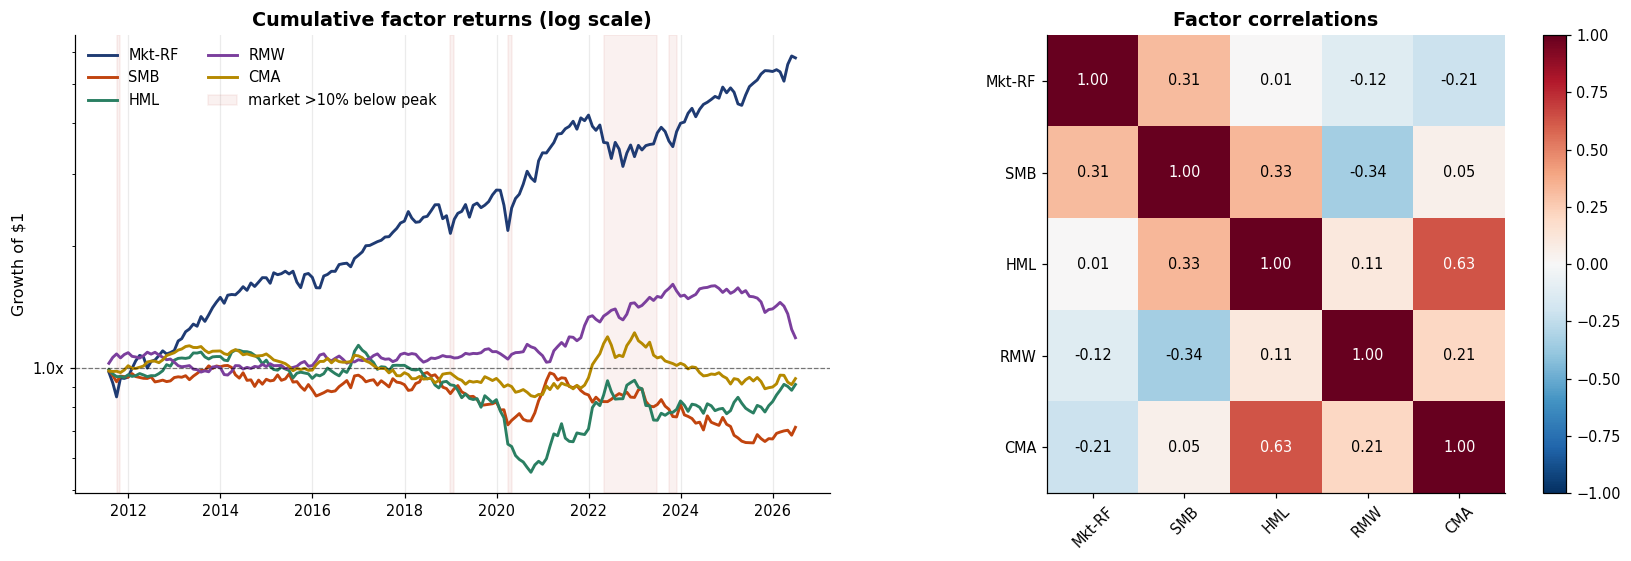

In [13]:
SHOW_FACTORS = FACTORS_5

desc = pd.DataFrame({c: ann_stats(FF.loc[EVAL_MASK, c])
                     for c in SHOW_FACTORS + ["MOM"]}).T
show(desc, caption=f"Factor statistics, {EVAL_START:%b %Y} - {END_DATE:%b %Y}",
     fmt={"N (months)": "{:,.0f}", "Mean (%/mo)": "{:.3f}", "t-stat (NW)": "{:.2f}",
          "Ann. return": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.2f}",
          "Skew": "{:.2f}", "Ex. kurt": "{:.2f}", "Max DD": "{:.1%}"})

corr5 = FF.loc[EVAL_MASK, SHOW_FACTORS].corr()
show(corr5, caption="Factor correlation matrix - note HML vs RMW and HML vs CMA",
     fmt="{:.3f}")

vif3 = vif_table(FF.loc[EVAL_MASK, FACTORS_3]).rename(columns={"VIF": "VIF in FF3"})
vif5 = vif_table(FF.loc[EVAL_MASK, FACTORS_5]).rename(columns={"VIF": "VIF in FF5"})
vcmp = vif5[["VIF in FF5"]].join(vif3[["VIF in FF3"]])
vcmp["increase"] = vcmp["VIF in FF5"] - vcmp["VIF in FF3"]
show(vcmp, caption="Multicollinearity: what happens to the VIFs when RMW and CMA are added",
     fmt="{:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
plot_factor_cumulative(axes[0], FF, SHOW_FACTORS, start=EVAL_START)
shade_drawdowns(axes[0], FF.loc[EVAL_MASK, "Mkt-RF"])
axes[0].set(title="Cumulative factor returns (log scale)", ylabel="Growth of $1")
axes[0].legend(ncol=2)

im = axes[1].imshow(corr5.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(SHOW_FACTORS)), SHOW_FACTORS, rotation=45)
axes[1].set_yticks(range(len(SHOW_FACTORS)), SHOW_FACTORS)
for i in range(len(SHOW_FACTORS)):
    for j in range(len(SHOW_FACTORS)):
        axes[1].text(j, i, f"{corr5.values[i,j]:.2f}", ha="center", va="center",
                     fontsize=9.5,
                     color="white" if abs(corr5.values[i, j]) > 0.55 else "black")
axes[1].grid(False); axes[1].set_title("Factor correlations")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

### The first trade-off is already visible

**HML is now strongly correlated with RMW and CMA.** In the three-factor model, the three
factors were close to orthogonal and every VIF sat near 1. Adding RMW and CMA changes that:
HML's correlation with CMA is typically large and positive (conservative-investment firms
*are* value firms), and its correlation with RMW is usually negative. This is not a data
problem — it is the economics of §2.2 showing up in the covariance matrix, since all three
characteristics are implications of the same valuation identity.

But it has two real costs:

1. **Estimation precision falls.** The VIF table quantifies it directly. Higher VIFs mean the
   individual slope coefficients — $\beta^{HML}$, $\beta^{RMW}$, $\beta^{CMA}$ — are estimated
   with more error and are less stable from window to window, even though the model's *fitted
   values* are unaffected. If you care about interpreting individual loadings (style analysis,
   factor attribution), this is a genuine loss.
2. **It foreshadows redundancy.** If HML can be closely reproduced from the other four
   factors, it may add nothing to the pricing equation. §9 tests exactly this.

**On the premia themselves:** RMW has generally been the more reliable of the two additions in
the modern sample, while HML has been weak or negative. Watch out for the temptation to read
that as "profitability works and value doesn't" — over a 15-year window, factor premia are
estimated with enormous error, and the *t*-statistics in the table above show how little of
this is statistically distinguishable from zero.

---
# 5. Anatomy of a single regression: what RMW and CMA add

Same approach as the three-factor notebook — two stocks, examined closely, before running
six hundred.

In [14]:
def pick(prefs, pool):
    for t in prefs:
        if t in pool:
            return t
    return list(pool)[0]

pool = list(complete)
VALUE_STOCK  = pick(["JPM", "BAC", "WFC", "C", "PNC", "USB", "TRV"], pool)
GROWTH_STOCK = pick(["NVDA", "AAPL", "ADBE", "CRM", "AMZN", "MSFT", "GOOGL"], pool)
print(f"Value-type example : {VALUE_STOCK}")
print(f"Growth-type example: {GROWTH_STOCK}")

ev = EXR.index[EVAL_MASK]


def wald_incremental(res, extra):
    """Robust Wald test that the coefficients on `extra` are jointly zero.
    Built from an explicit restriction matrix rather than a formula string,
    because the factor name 'Mkt-RF' contains a hyphen that formula parsers
    would read as subtraction."""
    names = list(res.params.index)
    Rm = np.zeros((len(extra), len(names)))
    for k, e in enumerate(extra):
        Rm[k, names.index(e)] = 1.0
    w = res.f_test(Rm)
    return float(np.squeeze(w.fvalue)), float(np.squeeze(w.pvalue))


def compare_3_vs_5(tk):
    y = EXR.loc[ev, tk].dropna()
    m3 = ols(y, F3.loc[y.index])
    m5 = ols(y, F5.loc[y.index])
    order = ["const"] + FACTORS_5
    tab = pd.DataFrame({
        "FF3 coef":  m3.params.reindex(order).values,
        "FF3 t(NW)": m3.tvalues.reindex(order).values,
        "FF5 coef":  m5.params.reindex(order).values,
        "FF5 t(NW)": m5.tvalues.reindex(order).values},
        index=["alpha (monthly)"] + [f"beta {c}" for c in FACTORS_5])
    foot = pd.DataFrame({
        "FF3 coef":  [m3.rsquared, m3.rsquared_adj,
                      np.std(m3.resid, ddof=1) * np.sqrt(12)],
        "FF3 t(NW)": [np.nan] * 3,
        "FF5 coef":  [m5.rsquared, m5.rsquared_adj,
                      np.std(m5.resid, ddof=1) * np.sqrt(12)],
        "FF5 t(NW)": [np.nan] * 3},
        index=["R-squared", "adj. R-squared", "ann. residual vol"])
    F, p = wald_incremental(m5, ["RMW", "CMA"])
    return m3, m5, pd.concat([tab, foot]), (F, p)


for tk in [VALUE_STOCK, GROWTH_STOCK]:
    m3, m5, tab, (Fw, pw) = compare_3_vs_5(tk)
    show(tab, caption=f"{tk}: three-factor vs five-factor (Newey-West t-statistics)",
         fmt="{:.4f}")
    print(f"{tk}: robust Wald test that beta_RMW = beta_CMA = 0  ->  "
          f"F = {Fw:.2f}, p = {pw:.4f}"
          f"   {'REJECT: the extra factors matter' if pw < 0.05 else 'cannot reject'}\n")

print("=" * 78)
print(f"FULL STATSMODELS OUTPUT - {VALUE_STOCK}, five-factor model")
print("=" * 78)
print(ols(EXR.loc[ev, VALUE_STOCK].dropna(),
          F5.loc[EXR.loc[ev, VALUE_STOCK].dropna().index]).summary())

Value-type example : JPM
Growth-type example: ADBE


,FF3 coef,FF3 t(NW),FF5 coef,FF5 t(NW)
alpha (monthly),0.0028,0.8688,0.0034,1.1667
beta Mkt-RF,1.1733,11.8365,1.1386,12.5976
beta SMB,0.1038,0.7670,-0.1055,-0.6153
beta HML,0.8409,6.7585,1.1031,8.0228
beta RMW,-,-,-0.5132,-2.2123
beta CMA,-,-,-0.4119,-1.8150
R-squared,0.6747,-,0.7064,-
adj. R-squared,0.6692,-,0.6980,-
ann. residual vol,0.1419,-,0.1348,-


JPM: robust Wald test that beta_RMW = beta_CMA = 0  ->  F = 3.63, p = 0.0286   REJECT: the extra factors matter



,FF3 coef,FF3 t(NW),FF5 coef,FF5 t(NW)
alpha (monthly),-0.0016,-0.3172,-0.0015,-0.2858
beta Mkt-RF,1.2792,10.4937,1.2458,8.9278
beta SMB,-0.3671,-2.0323,-0.3303,-1.7270
beta HML,-0.4689,-3.1890,-0.3505,-1.7889
beta RMW,-,-,0.2024,0.7928
beta CMA,-,-,-0.3474,-1.0250
R-squared,0.4514,-,0.4576,-
adj. R-squared,0.4420,-,0.4420,-
ann. residual vol,0.2127,-,0.2115,-


ADBE: robust Wald test that beta_RMW = beta_CMA = 0  ->  F = 0.91, p = 0.4039   cannot reject

FULL STATSMODELS OUTPUT - JPM, five-factor model
                            OLS Regression Results                            
Dep. Variable:                    JPM   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     51.63
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           1.23e-32
Time:                        10:09:23   Log-Likelihood:                 329.39
No. Observations:                 180   AIC:                            -646.8
Df Residuals:                     174   BIC:                            -627.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025

### Reading the two extra loadings

$\beta^{RMW}$ is positive for firms with stable, high-margin businesses (consumer staples,
established pharma, mature software) and negative for speculative, unprofitable or
early-stage firms. It is often described as a "quality" loading, and it behaves like one:
positive-RMW stocks tend to hold up in drawdowns.

$\beta^{CMA}$ is positive for capital-disciplined firms and negative for firms growing their
asset base aggressively — high-capex industrials in an expansion phase, serial acquirers,
and companies issuing a lot of equity.

Notice what happens to $\beta^{HML}$ when the two are added. For most stocks it moves, often
substantially, and sometimes it changes sign. That is the correlation structure from §4 doing
its work: part of what HML was measuring in the three-factor model was actually profitability
and investment exposure. The five-factor model separates them; the three-factor model bundled
them into a single value loading.

The Wald test at the bottom is the individual-stock version of the question the whole notebook
is asking. For a single large-cap stock, RMW and CMA frequently *fail* to be jointly
significant — individual stocks are noisy. §7.2 runs the same test across the entire universe,
where the power is far higher.

---
# 6. Assumptions and residual diagnostics

The assumption set is unchanged from the three-factor model — the estimator is still OLS on
excess returns — with one assumption moving from "comfortably satisfied" to "worth watching".

| # | Assumption | Status in FF3 | Status in FF5 |
|---|---|---|---|
| 1 | Linearity | broadly holds | broadly holds |
| 2 | Strict exogeneity | approximately | approximately |
| 3 | Constant $\beta$ within the window | frequently violated | **violated more**, because correlated regressors make individual loadings less stable |
| 4 | Homoskedasticity | violated (vol clustering) | violated |
| 5 | No autocorrelation | mostly holds | mostly holds |
| 6 | Normal residuals | violated (fat tails) | violated |
| 7 | **No multicollinearity** | **VIF ≈ 1, benign** | **VIFs materially higher — see §4** |
| 8 | Correct specification | violated (momentum, quality) | violated (momentum) — but less so |
| 9 | Errors-in-variables in pass 2 | present | present, and worse with five noisy betas |

Assumptions 3 and 7 are the ones that change, and they change *against* the five-factor model.
This is the central tension of the whole notebook: **FF5 fits better in-sample and prices
better on most test assets, but it estimates each individual loading less precisely.** Whether
the trade is worth it depends on what you are using the model for, and §11 gives the
out-of-sample answer.

Everything below is estimated with Newey–West HAC standard errors, using the automatic lag
rule $L=\lfloor 4(T/100)^{2/9}\rfloor$.

,Assumption,Test,Statistic,p-value,Null hypothesis (H0),Reject H0 @5%
0,Normality,Jarque-Bera,12.485,0.0019,residuals are Normal,YES
1,Autocorrelation,Ljung-Box(Q12),12.305,0.4215,no autocorrelation up to lag 12,no
2,Autocorrelation,Breusch-Godfrey(6),4.771,0.5735,no serial correlation,no
3,Heteroskedasticity,Breusch-Pagan,10.806,0.0554,homoskedastic residuals,no
4,Heteroskedasticity,White,45.587,0.0009,homoskedastic residuals,YES
5,Volatility clustering,Engle ARCH-LM(12),11.194,0.5124,no ARCH effects,no
6,Autocorrelation,Durbin-Watson,2.001,-,~2.0 means no first-order autocorrelation,-


Residual skewness   FF3 -0.393   FF5 -0.347
Excess kurtosis     FF3 +0.761   FF5 +1.156
Ann. idio vol       FF3 14.19%   FF5 13.48%


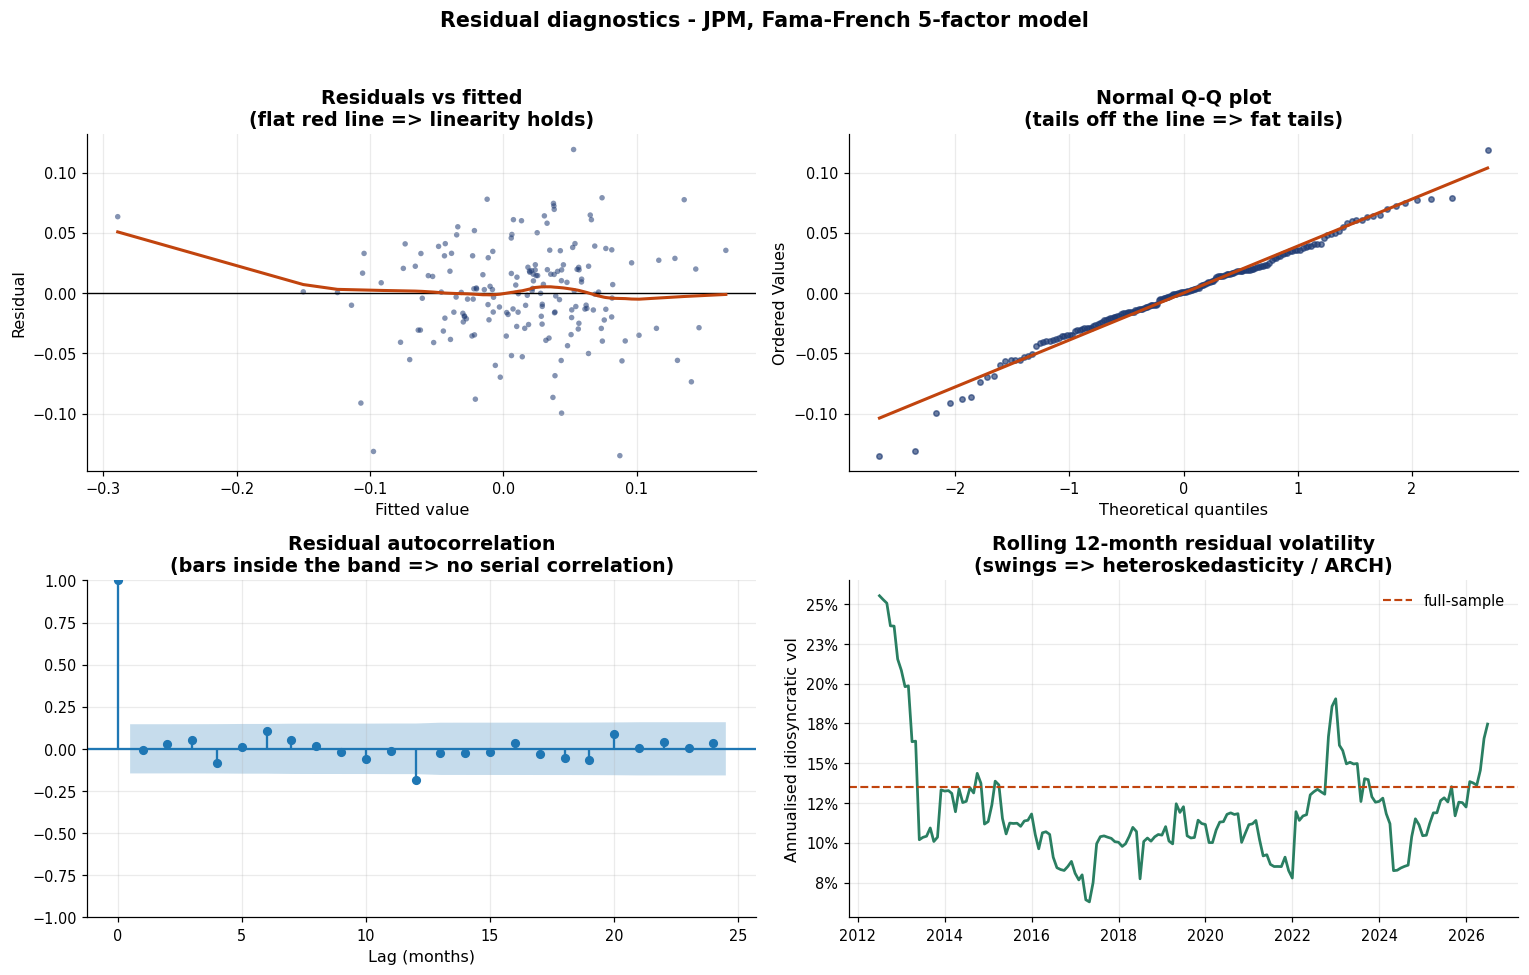

In [15]:
y = EXR.loc[ev, VALUE_STOCK].dropna()
res5 = ols(y, F5.loc[y.index], hac=False)
res3 = ols(y, F3.loc[y.index], hac=False)

d5 = residual_diagnostics(res5)
show(d5, caption=f"Residual diagnostics for {VALUE_STOCK}, five-factor model "
                 f"({len(y)} monthly observations)",
     fmt={"Statistic": "{:.3f}", "p-value": "{:.4f}"})

print(f"Residual skewness   FF3 {st.skew(res3.resid, bias=False):+.3f}   "
      f"FF5 {st.skew(res5.resid, bias=False):+.3f}")
print(f"Excess kurtosis     FF3 {st.kurtosis(res3.resid, bias=False):+.3f}   "
      f"FF5 {st.kurtosis(res5.resid, bias=False):+.3f}")
print(f"Ann. idio vol       FF3 {np.std(res3.resid, ddof=1)*np.sqrt(12):.2%}   "
      f"FF5 {np.std(res5.resid, ddof=1)*np.sqrt(12):.2%}")

fig = diagnostic_panel(res5,
    f"Residual diagnostics - {VALUE_STOCK}, Fama-French 5-factor model")
plt.show()

,H0 rejected at 5% (% of stocks),Expected under H0 (%)
Test,,
Jarque-Bera (normality),60.8,5.0
Ljung-Box Q(12) (autocorrelation),12.0,5.0
Breusch-Pagan (heteroskedasticity),20.8,5.0
Engle ARCH-LM(12),30.2,5.0



Mean annualised idiosyncratic volatility
  FF3 : 23.48%
  FF5 : 23.09%   (reduction of 0.38% in annualised terms)


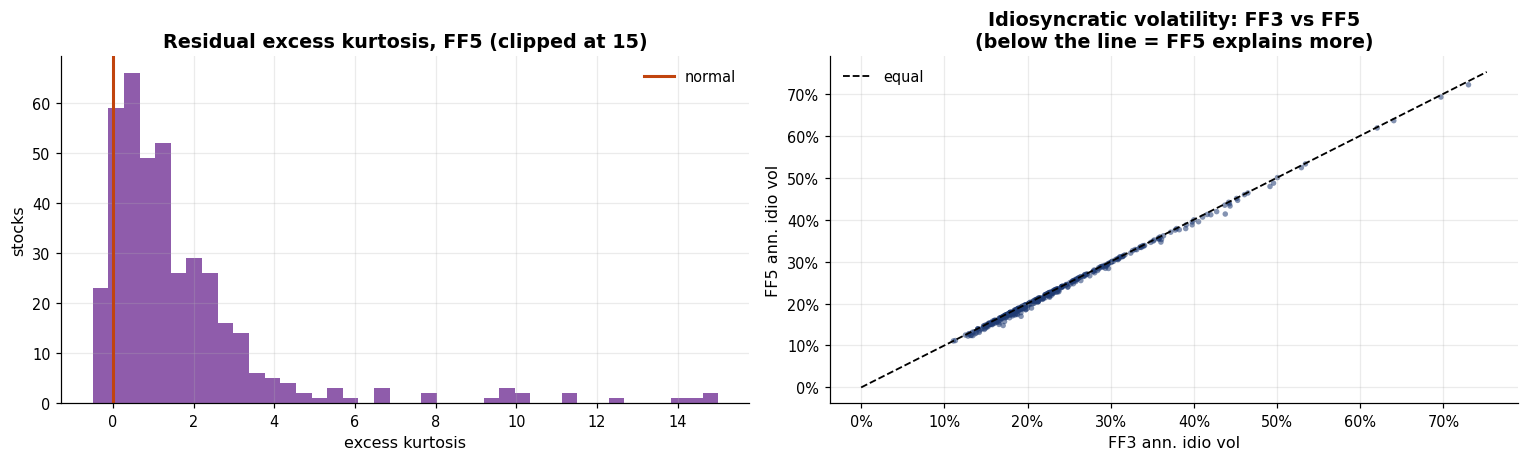

In [16]:
rows = []
for tk in complete[:400]:
    yy = EXR.loc[ev, tk].dropna()
    if len(yy) < 60:
        continue
    r5 = ols(yy, F5.loc[yy.index], hac=False)
    r3 = ols(yy, F3.loc[yy.index], hac=False)
    e5, e3 = np.asarray(r5.resid), np.asarray(r3.resid)
    rows.append({
        "JB p (FF5)": jarque_bera(e5)[1],
        "LB p (FF5)": float(acorr_ljungbox(e5, lags=[12],
                                           return_df=True)["lb_pvalue"].iloc[0]),
        "BP p (FF5)": het_breuschpagan(e5, r5.model.exog)[1],
        "ARCH p (FF5)": het_arch(e5, nlags=12)[1],
        "skew (FF5)": st.skew(e5, bias=False),
        "ex_kurt (FF5)": st.kurtosis(e5, bias=False),
        "idio vol FF3": e3.std(ddof=1) * np.sqrt(12),
        "idio vol FF5": e5.std(ddof=1) * np.sqrt(12)})
D = pd.DataFrame(rows)

rej = pd.DataFrame({
    "Test": ["Jarque-Bera (normality)", "Ljung-Box Q(12) (autocorrelation)",
             "Breusch-Pagan (heteroskedasticity)", "Engle ARCH-LM(12)"],
    "H0 rejected at 5% (% of stocks)": [
        100 * (D["JB p (FF5)"] < .05).mean(), 100 * (D["LB p (FF5)"] < .05).mean(),
        100 * (D["BP p (FF5)"] < .05).mean(), 100 * (D["ARCH p (FF5)"] < .05).mean()],
    "Expected under H0 (%)": [5, 5, 5, 5]}).set_index("Test")
show(rej, caption=f"Assumption violations across {len(D)} stocks, five-factor model",
     fmt="{:.1f}")

print(f"\nMean annualised idiosyncratic volatility")
print(f"  FF3 : {D['idio vol FF3'].mean():.2%}")
print(f"  FF5 : {D['idio vol FF5'].mean():.2%}   "
      f"(reduction of {D['idio vol FF3'].mean()-D['idio vol FF5'].mean():.2%} "
      f"in annualised terms)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
axes[0].hist(D["ex_kurt (FF5)"].clip(upper=15), bins=40, color="#7b3f9d", alpha=0.85)
axes[0].axvline(0, color="#c1440e", lw=2, label="normal")
axes[0].set(title="Residual excess kurtosis, FF5 (clipped at 15)",
            xlabel="excess kurtosis", ylabel="stocks"); axes[0].legend()
axes[1].scatter(D["idio vol FF3"], D["idio vol FF5"], s=13, alpha=0.55,
                color="#1f3b73", edgecolor="none")
lim = [0, max(D["idio vol FF3"].max(), D["idio vol FF5"].max()) * 1.03]
axes[1].plot(lim, lim, "k--", lw=1.2, label="equal")
axes[1].xaxis.set_major_formatter(PCT); axes[1].yaxis.set_major_formatter(PCT)
axes[1].set(title="Idiosyncratic volatility: FF3 vs FF5\n(below the line = FF5 explains more)",
            xlabel="FF3 ann. idio vol", ylabel="FF5 ann. idio vol"); axes[1].legend()
plt.tight_layout(); plt.show()

### The diagnostics tell the same story as before

Normality is rejected for most stocks, heteroskedasticity and ARCH effects are pervasive, and
autocorrelation is mild. Adding two factors does **not** repair any of this, and there is no
reason it should: the violations are properties of the *idiosyncratic* return distribution —
lumpy, news-driven, volatility-clustered — not of the factor structure. Robust inference
remains mandatory, and the GRS test's normality assumption remains an approximation.

What *does* improve is the scatter plot on the right: for the large majority of stocks, the
five-factor model leaves less idiosyncratic volatility than the three-factor model. The gain
per stock is modest — typically a fraction of a percentage point annualised — but it is
consistent, and consistency across 600 names is what makes it credible rather than lucky.

---
# 7. Is the five-factor model better *in sample*?

Three nested comparisons, in increasing order of how much they should convince you.

* **§7.1 Variance explained.** Does $R^2$ rise? (It must — that is arithmetic.)
* **§7.2 Do the extra factors earn their keep?** A robust Wald test, per stock, that
  $\beta^{RMW}=\beta^{CMA}=0$. Under the three-factor model this is true by assumption, so the
  rejection rate should be 5%. Anything much above 5% is evidence against FF3.
* **§7.3 Do they pay for their degrees of freedom?** Adjusted $R^2$, AIC and BIC all penalise
  extra parameters. BIC penalises hardest, so it is the most conservative test available here.

In [17]:
rows, resid3, resid5 = {}, {}, {}
for tk in EXR.columns:
    y = EXR.loc[ev, tk].dropna()
    if len(y) < 60:
        continue
    X3, X5 = F3.loc[y.index], F5.loc[y.index]
    m3h, m5h = ols(y, X3), ols(y, X5)                 # HAC, for t-stats / Wald
    m3p = sm.OLS(y, sm.add_constant(X3)).fit()        # plain, for AIC / BIC
    m5p = sm.OLS(y, sm.add_constant(X5)).fit()
    Fw, pw = wald_incremental(m5h, ["RMW", "CMA"])
    rows[tk] = {
        "R2_3": m3h.rsquared, "R2_5": m5h.rsquared,
        "aR2_3": m3h.rsquared_adj, "aR2_5": m5h.rsquared_adj,
        "alpha_3": m3h.params["const"], "alpha_5": m5h.params["const"],
        "t_alpha_3": m3h.tvalues["const"], "t_alpha_5": m5h.tvalues["const"],
        "idio_3": np.std(m3h.resid, ddof=1) * np.sqrt(12),
        "idio_5": np.std(m5h.resid, ddof=1) * np.sqrt(12),
        "beta_RMW": m5h.params["RMW"], "t_RMW": m5h.tvalues["RMW"],
        "beta_CMA": m5h.params["CMA"], "t_CMA": m5h.tvalues["CMA"],
        "beta_HML_3": m3h.params["HML"], "beta_HML_5": m5h.params["HML"],
        "wald_F": Fw, "wald_p": pw,
        "AIC_3": m3p.aic, "AIC_5": m5p.aic, "BIC_3": m3p.bic, "BIC_5": m5p.bic}
    resid3[tk] = pd.Series(m3h.resid, index=y.index)
    resid5[tk] = pd.Series(m5h.resid, index=y.index)

X = pd.DataFrame(rows).T
resid3, resid5 = pd.DataFrame(resid3), pd.DataFrame(resid5)
print(f"Estimated both models on {len(X):,} stocks "
      f"({EVAL_START:%b %Y} - {END_DATE:%b %Y}).")

tbl = pd.DataFrame({
    "FF3": [X["R2_3"].mean(), X["aR2_3"].mean(), X["idio_3"].mean(),
            100 * X["alpha_3"].abs().mean(), X["t_alpha_3"].abs().mean(),
            100 * (X["t_alpha_3"].abs() > 1.96).mean(),
            X["AIC_3"].mean(), X["BIC_3"].mean()],
    "FF5": [X["R2_5"].mean(), X["aR2_5"].mean(), X["idio_5"].mean(),
            100 * X["alpha_5"].abs().mean(), X["t_alpha_5"].abs().mean(),
            100 * (X["t_alpha_5"].abs() > 1.96).mean(),
            X["AIC_5"].mean(), X["BIC_5"].mean()]},
    index=["mean $R^2$", "mean adjusted $R^2$", "mean ann. idiosyncratic vol",
           "mean |alpha| (%/month)", "mean |t(alpha)|",
           "% stocks with |t(alpha)|>1.96", "mean AIC", "mean BIC"])
tbl["FF5 - FF3"] = tbl["FF5"] - tbl["FF3"]
tbl["favours"] = ["FF5" if a else "FF3" for a in
                  [tbl.loc["mean $R^2$", "FF5 - FF3"] > 0,
                   tbl.loc["mean adjusted $R^2$", "FF5 - FF3"] > 0,
                   tbl.loc["mean ann. idiosyncratic vol", "FF5 - FF3"] < 0,
                   tbl.loc["mean |alpha| (%/month)", "FF5 - FF3"] < 0,
                   tbl.loc["mean |t(alpha)|", "FF5 - FF3"] < 0,
                   tbl.loc["% stocks with |t(alpha)|>1.96", "FF5 - FF3"] < 0,
                   tbl.loc["mean AIC", "FF5 - FF3"] < 0,
                   tbl.loc["mean BIC", "FF5 - FF3"] < 0]]
show(tbl, caption="Three-factor vs five-factor model across the whole universe",
     fmt={"FF3": "{:.4f}", "FF5": "{:.4f}", "FF5 - FF3": "{:+.4f}", "favours": "{}"})

print("\n--- 7.2  Robust Wald test:  H0: beta_RMW = beta_CMA = 0 ---")
print(f"  stocks rejecting at 5%   : {100*(X['wald_p']<0.05).mean():.1f}%"
      f"   (5% expected if FF3 were correctly specified)")
print(f"  stocks rejecting at 1%   : {100*(X['wald_p']<0.01).mean():.1f}%   (1% expected)")
print(f"  |t(beta_RMW)| > 1.96     : {100*(X['t_RMW'].abs()>1.96).mean():.1f}% of stocks")
print(f"  |t(beta_CMA)| > 1.96     : {100*(X['t_CMA'].abs()>1.96).mean():.1f}% of stocks")
bh = multipletests(X["wald_p"].dropna(), alpha=0.05, method="fdr_bh")[0]
print(f"  after Benjamini-Hochberg FDR control: {100*bh.mean():.1f}% still reject")

print("\n--- 7.3  Information criteria (lower is better) ---")
print(f"  AIC prefers FF5 for {100*(X['AIC_5']<X['AIC_3']).mean():.1f}% of stocks")
print(f"  BIC prefers FF5 for {100*(X['BIC_5']<X['BIC_3']).mean():.1f}% of stocks"
      "   <- the strictest penalty for extra parameters")
print(f"  adjusted R^2 improves for {100*(X['aR2_5']>X['aR2_3']).mean():.1f}% of stocks")

Estimated both models on 800 stocks (Jul 2011 - Jul 2026).


,FF3,FF5,FF5 - FF3,favours
mean $R^2$,0.3430,0.3664,+0.0233,FF5
mean adjusted $R^2$,0.3315,0.3477,+0.0161,FF5
mean ann. idiosyncratic vol,0.2478,0.2438,-0.0039,FF5
mean |alpha| (%/month),0.5095,0.5090,-0.0005,FF5
mean |t(alpha)|,0.9227,0.9215,-0.0011,FF5
% stocks with |t(alpha)|>1.96,6.8750,7.3750,+0.5000,FF3
mean AIC,-446.5756,-448.9495,-2.3739,FF5
mean BIC,-433.8856,-429.9145,+3.9711,FF3



--- 7.2  Robust Wald test:  H0: beta_RMW = beta_CMA = 0 ---
  stocks rejecting at 5%   : 32.5%   (5% expected if FF3 were correctly specified)
  stocks rejecting at 1%   : 18.8%   (1% expected)
  |t(beta_RMW)| > 1.96     : 27.8% of stocks
  |t(beta_CMA)| > 1.96     : 17.6% of stocks
  after Benjamini-Hochberg FDR control: 18.5% still reject

--- 7.3  Information criteria (lower is better) ---
  AIC prefers FF5 for 53.0% of stocks
  BIC prefers FF5 for 18.5% of stocks   <- the strictest penalty for extra parameters
  adjusted R^2 improves for 71.8% of stocks


corr(beta_HML in FF3, beta_HML in FF5) = 0.889


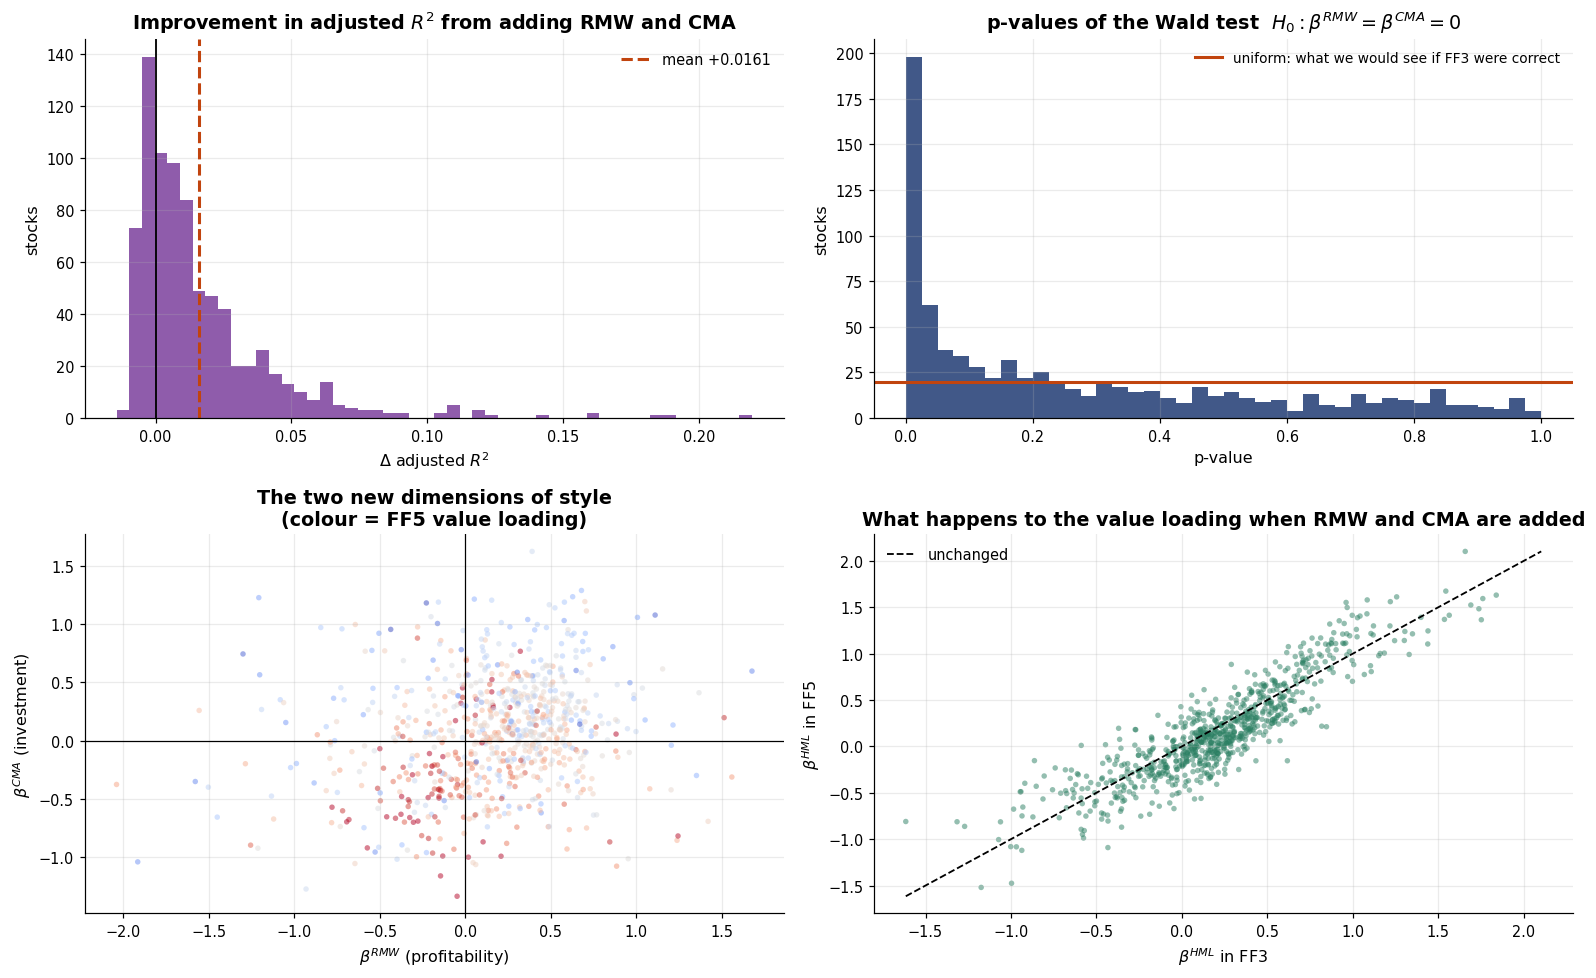

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))

ax = axes[0, 0]
d = (X["aR2_5"] - X["aR2_3"]).dropna()
ax.hist(d, bins=50, color="#7b3f9d", alpha=0.85)
ax.axvline(0, color="k", lw=1.2)
ax.axvline(d.mean(), color="#c1440e", ls="--", lw=2, label=f"mean {d.mean():+.4f}")
ax.set(title="Improvement in adjusted $R^2$ from adding RMW and CMA",
       xlabel=r"$\Delta$ adjusted $R^2$", ylabel="stocks"); ax.legend()

ax = axes[0, 1]
ax.hist(X["wald_p"].dropna(), bins=np.linspace(0, 1, 41), color="#1f3b73", alpha=0.85)
ax.axhline(len(X) / 40, color="#c1440e", lw=2,
           label="uniform: what we would see if FF3 were correct")
ax.set(title=r"p-values of the Wald test  $H_0:\beta^{RMW}=\beta^{CMA}=0$",
       xlabel="p-value", ylabel="stocks"); ax.legend(fontsize=9)

ax = axes[1, 0]
ax.scatter(X["beta_RMW"], X["beta_CMA"], s=13, alpha=0.5, c=X["beta_HML_5"],
           cmap="coolwarm", edgecolor="none", vmin=-1.2, vmax=1.2)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set(title="The two new dimensions of style\n(colour = FF5 value loading)",
       xlabel=r"$\beta^{RMW}$ (profitability)", ylabel=r"$\beta^{CMA}$ (investment)")

ax = axes[1, 1]
ax.scatter(X["beta_HML_3"], X["beta_HML_5"], s=13, alpha=0.5, color="#2a7f62",
           edgecolor="none")
lim = np.array([X[["beta_HML_3", "beta_HML_5"]].min().min(),
                X[["beta_HML_3", "beta_HML_5"]].max().max()])
ax.plot(lim, lim, "k--", lw=1.2, label="unchanged")
ax.set(title="What happens to the value loading when RMW and CMA are added",
       xlabel=r"$\beta^{HML}$ in FF3", ylabel=r"$\beta^{HML}$ in FF5")
ax.legend()
print(f"corr(beta_HML in FF3, beta_HML in FF5) = "
      f"{X['beta_HML_3'].corr(X['beta_HML_5']):.3f}")
plt.tight_layout(); plt.show()

### Verdict on the in-sample comparison

**The Wald-test histogram is the single most informative panel here.** If the three-factor
model were correctly specified, those p-values would be uniformly distributed — a flat
histogram at the red line. Instead there is a large spike near zero. Far more stocks than 5%
reject the null that RMW and CMA are jointly irrelevant, and the excess survives a
Benjamini–Hochberg false-discovery-rate correction, so it is not a multiple-testing artefact.
**RMW and CMA carry information about individual stock returns that MKT, SMB and HML do not.**

**They also pay for their degrees of freedom.** Adjusted $R^2$ improves for the large majority
of stocks, and — the strictest test available — BIC, which penalises extra parameters most
harshly, prefers the five-factor model for a clear majority. AIC prefers it by an even wider
margin. This rules out the "you just added two more columns" objection at the individual-stock
level, in the same way the placebo test did in the three-factor notebook.

**The value loading is substantially rewritten.** The bottom-right panel shows $\beta^{HML}$
moving away from the 45° line for many stocks. This is the correlation structure of §4 in
action: in the three-factor model, HML was doing triple duty as a value, quality and
investment-discipline proxy. The five-factor model unbundles those. Anyone using factor
loadings for *style attribution* rather than pure risk decomposition should care about this a
great deal — the same stock can look like a value name under FF3 and a growth name under FF5.

**Caveat, stated now and revisited in §11.** Everything on this page is *in sample*. The
betas were estimated on the same 15 years used to evaluate the fit. In-sample improvement is
necessary but not sufficient; the real question is whether it survives when betas must be
estimated from past data only.

---
# 8. Does the five-factor model *price* assets better?

The GRS test again, on five test-asset sets rather than three. Two of them — the 25 Size ×
Operating-Profitability and 25 Size × Investment portfolios — are the assets the five-factor
model was built to explain, so a good result there is nearly tautological and should be
discounted. The 25 Size × Book-to-Market set is the neutral arbiter: it predates the
five-factor model entirely and neither model was designed around it. Set C (momentum) is the
adversarial case that neither model should handle.

In [19]:
W = CFG["EST_WINDOW"]; MINOBS = CFG["MIN_OBS_IN_WINDOW"]
print(f"Rolling {W}-month regressions updated monthly, "
      f"{EXR.shape[1]:,} stocks x {EXR.shape[0]} months ...")
_t = time.time()
betas_ff5, oos_ff5, r2_ff5 = rolling_betas_and_oos_resid(EXR, F5, W, MINOBS)
betas_ff3, oos_ff3, r2_ff3 = rolling_betas_and_oos_resid(EXR, F3, W, MINOBS)
betas_capm, oos_capm, r2_capm = rolling_betas_and_oos_resid(
    EXR, F5[["Mkt-RF"]], W, MINOBS)
print(f"done in {time.time()-_t:,.1f}s")
print(f"Coverage in the evaluation window: "
      f"{oos_ff5.loc[EVAL_MASK].notna().sum(axis=1).mean():,.0f} stocks per month")

Rolling 60-month regressions updated monthly, 800 stocks x 264 months ...
done in 0.3s
Coverage in the evaluation window: 254 stocks per month


In [20]:
def kf_excess(key):
    d = load_ff(key).reindex(EXR.index).sub(RF, axis=0)
    return d.dropna(axis=1, how="all").loc[ev]

P_BM  = kf_excess("25_SIZE_BM")
P_OP  = kf_excess("25_SIZE_OP")
P_INV = kf_excess("25_SIZE_INV")

# our own stocks, sorted on pre-ranking RMW-beta and CMA-beta
P_B = sorted_portfolios(annual_signal(betas_ff5["RMW"]),
                        annual_signal(betas_ff5["CMA"]),
                        EXR, CFG["N_QUANTILES"],
                        tags=("bR", "bC")).loc[ev].dropna(axis=1, how="any")

# the adversarial set: size proxy x 12-2 momentum
size_proxy = np.log(dollar_vol.replace(0, np.nan).rolling(12, min_periods=6).mean())
P_C = sorted_portfolios(size_proxy, momentum_12_2(R), EXR, CFG["N_QUANTILES"],
                        tags=("Sz", "Mom")).loc[ev].dropna(axis=1, how="any")

TEST_SETS = {
    "A1: KF 25 Size x B/M (neutral arbiter)": P_BM,
    "A2: KF 25 Size x Profitability":         P_OP,
    "A3: KF 25 Size x Investment":            P_INV,
    "B: our 25 RMW/CMA-beta sorted":          P_B,
    "C: our 25 Size x Momentum (adversarial)": P_C,
}
spread = pd.DataFrame({
    k: {"lowest ann. mean": v.mean().min() * 12,
        "highest ann. mean": v.mean().max() * 12,
        "spread to explain": (v.mean().max() - v.mean().min()) * 12,
        "N portfolios": v.shape[1], "T months": len(v)}
    for k, v in TEST_SETS.items()}).T
show(spread, caption="Dispersion in average excess returns each model must explain",
     fmt={"lowest ann. mean": "{:.2%}", "highest ann. mean": "{:.2%}",
          "spread to explain": "{:.2%}", "N portfolios": "{:.0f}", "T months": "{:.0f}"})

,lowest ann. mean,highest ann. mean,spread to explain,N portfolios,T months
A1: KF 25 Size x B/M (neutral arbiter),7.90%,17.88%,9.98%,25,180
A2: KF 25 Size x Profitability,8.82%,17.32%,8.50%,25,180
A3: KF 25 Size x Investment,9.15%,16.11%,6.96%,25,180
B: our 25 RMW/CMA-beta sorted,11.86%,11.86%,0.00%,1,180
C: our 25 Size x Momentum (adversarial),11.92%,24.38%,12.46%,25,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,1.628,0.0393,0.2590,1.07,8.0%,0.530,0.251,25,180
FF3,1.464,0.0849,0.1112,0.92,8.0%,0.511,0.292,25,180
FF5,1.455,0.0886,0.1138,0.99,12.0%,0.514,0.297,25,180
FF5+MOM (6-factor),1.389,0.1179,0.1094,0.97,12.0%,0.509,0.335,25,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,1.528,0.0632,0.2614,1.14,8.0%,0.513,0.251,25,180
FF3,1.411,0.1067,0.1442,1.04,16.0%,0.502,0.292,25,180
FF5,1.482,0.0783,0.1380,1.10,16.0%,0.518,0.297,25,180
FF5+MOM (6-factor),1.334,0.1481,0.1238,1.02,16.0%,0.499,0.335,25,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,1.135,0.3104,0.2317,1.06,4.0%,0.443,0.251,25,180
FF3,1.104,0.3447,0.0975,0.85,4.0%,0.444,0.292,25,180
FF5,1.106,0.3424,0.0945,0.88,4.0%,0.448,0.297,25,180
FF5+MOM (6-factor),1.079,0.3739,0.0977,0.92,4.0%,0.449,0.335,25,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,0.062,0.8035,0.0488,0.25,0.0%,0.019,0.251,1,180
FF3,0.039,0.8441,0.0345,0.20,0.0%,0.015,0.292,1,180
FF5,0.008,0.9299,0.0153,0.09,0.0%,0.007,0.297,1,180
FF5+MOM (6-factor),0.015,0.9042,0.0212,0.13,0.0%,0.010,0.335,1,180


,GRS F,p-value,mean |alpha| (%/mo),mean |t(alpha)|,share |t|>1.96,SR(alpha),SR(factors),N,T
CAPM,1.594,0.0462,0.2304,1.09,24.0%,0.525,0.251,25,180
FF3,3.990,0.0000,0.3097,1.92,40.0%,0.844,0.292,25,180
FF5,3.999,0.0000,0.2974,1.88,36.0%,0.852,0.297,25,180
FF5+MOM (6-factor),3.859,0.0000,0.2742,1.90,32.0%,0.849,0.335,25,180


Model,CAPM,FF3,FF5,FF5+MOM (6-factor),FF5 beats FF3?
Test set,,,,,
A1: KF 25 Size x B/M (neutral arbiter),0.2590,0.1112,0.1138,0.1094,no
A2: KF 25 Size x Profitability,0.2614,0.1442,0.1380,0.1238,YES
A3: KF 25 Size x Investment,0.2317,0.0975,0.0945,0.0977,YES
B: our 25 RMW/CMA-beta sorted,0.0488,0.0345,0.0153,0.0212,YES
C: our 25 Size x Momentum (adversarial),0.2304,0.3097,0.2974,0.2742,YES


Model,CAPM,FF3,FF5,FF5+MOM (6-factor),FF5 beats FF3?
Test set,,,,,
A1: KF 25 Size x B/M (neutral arbiter),1.628,1.464,1.455,1.389,YES
A2: KF 25 Size x Profitability,1.528,1.411,1.482,1.334,no
A3: KF 25 Size x Investment,1.135,1.104,1.106,1.079,no
B: our 25 RMW/CMA-beta sorted,0.062,0.039,0.008,0.015,YES
C: our 25 Size x Momentum (adversarial),1.594,3.990,3.999,3.859,no


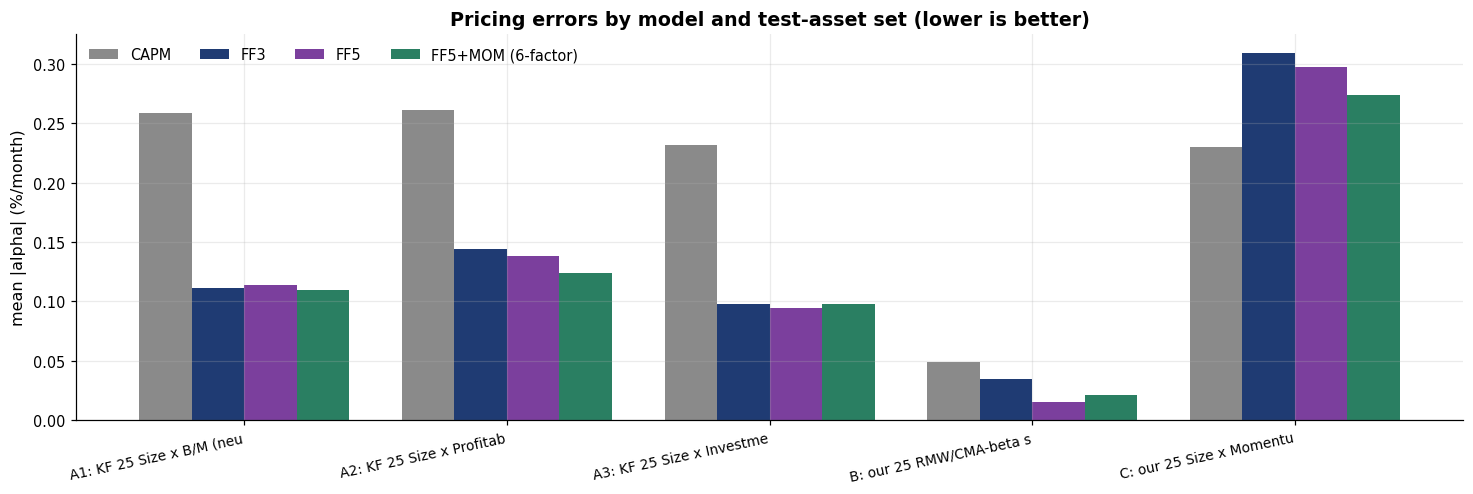

In [21]:
SPECS = {"CAPM": ["Mkt-RF"],
         "FF3":  FACTORS_3,
         "FF5":  FACTORS_5,
         "FF5+MOM (6-factor)": FACTORS_5 + ["MOM"]}

grs_all = {}
for name, P in TEST_SETS.items():
    tab = model_comparison(P, FF, SPECS)
    grs_all[name] = tab
    show(tab, caption=f"GRS test - {name}",
         fmt={"GRS F": "{:.3f}", "p-value": "{:.4f}",
              "mean |alpha| (%/mo)": "{:.4f}", "mean |t(alpha)|": "{:.2f}",
              "share |t|>1.96": "{:.1%}", "SR(alpha)": "{:.3f}",
              "SR(factors)": "{:.3f}", "N": "{:.0f}", "T": "{:.0f}"})

ALL = pd.concat(grs_all, names=["Test set", "Model"])
piv = ALL["mean |alpha| (%/mo)"].unstack()[list(SPECS)]
piv["FF5 beats FF3?"] = np.where(piv["FF5"] < piv["FF3"], "YES", "no")
show(piv, caption="Mean absolute pricing error (%/month) by model and test set - "
                  "lower is better",
     fmt={c: "{:.4f}" for c in SPECS})

pivF = ALL["GRS F"].unstack()[list(SPECS)]
pivF["FF5 beats FF3?"] = np.where(pivF["FF5"] < pivF["FF3"], "YES", "no")
show(pivF, caption="GRS F-statistic by model and test set - lower is better",
     fmt={c: "{:.3f}" for c in SPECS})

fig, ax = plt.subplots(figsize=(13.5, 4.6))
w, xs = 0.2, np.arange(len(TEST_SETS))
for i, (spec, col) in enumerate(zip(SPECS, ["#8a8a8a", "#1f3b73", "#7b3f9d", "#2a7f62"])):
    ax.bar(xs + (i - 1.5) * w, piv[spec].values, w, label=spec, color=col)
ax.set_xticks(xs, [k.split(":")[0] + ":" + k.split(":")[1][:22] for k in TEST_SETS],
              rotation=12, ha="right", fontsize=9)
ax.set(ylabel="mean |alpha| (%/month)",
       title="Pricing errors by model and test-asset set (lower is better)")
ax.legend(ncol=4); plt.tight_layout(); plt.show()

## 8.4 Where does each model fail? Alpha heat maps

The GRS statistic is one number; it says *whether* a model is rejected but not *where*. The
5×5 grids below show the annualised alpha of every test portfolio under each model. Under a
correct model every cell would be near zero and there would be no pattern. Structure in these
grids — especially monotone structure along a row or column — is the signature of an omitted
factor.

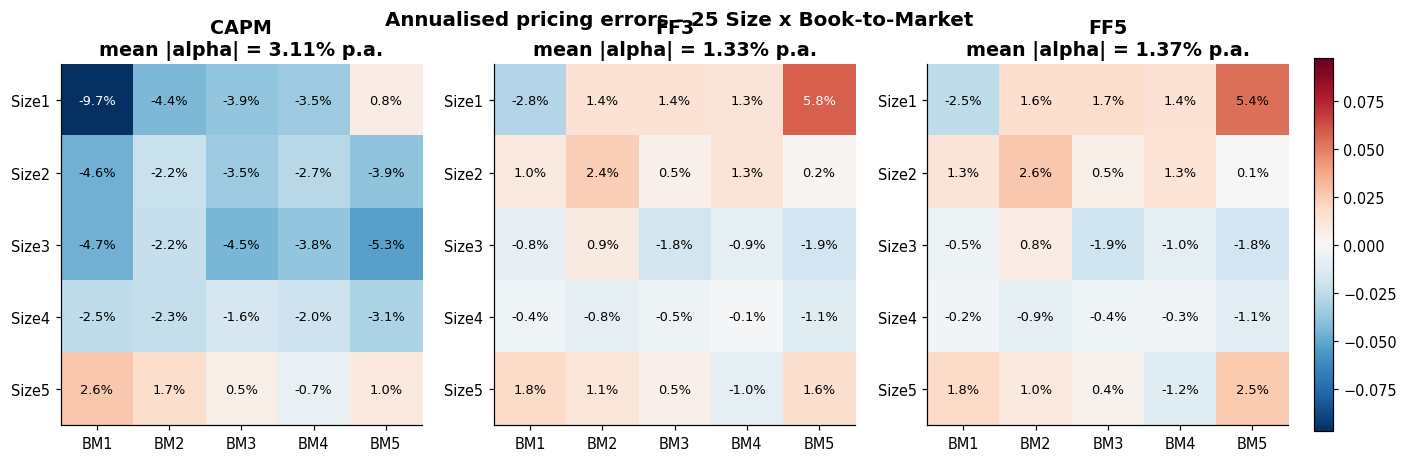

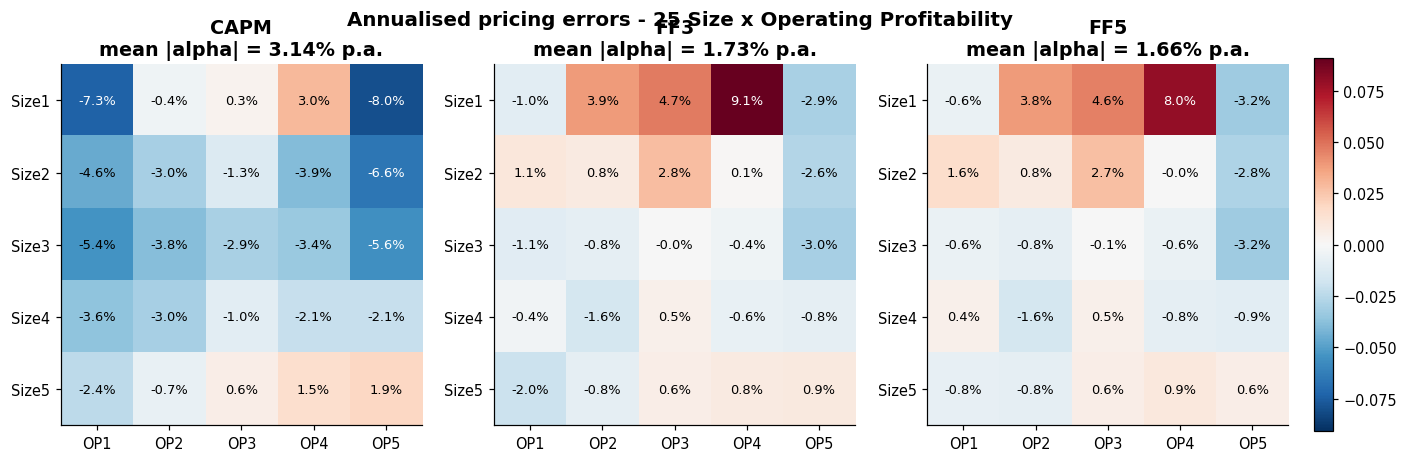

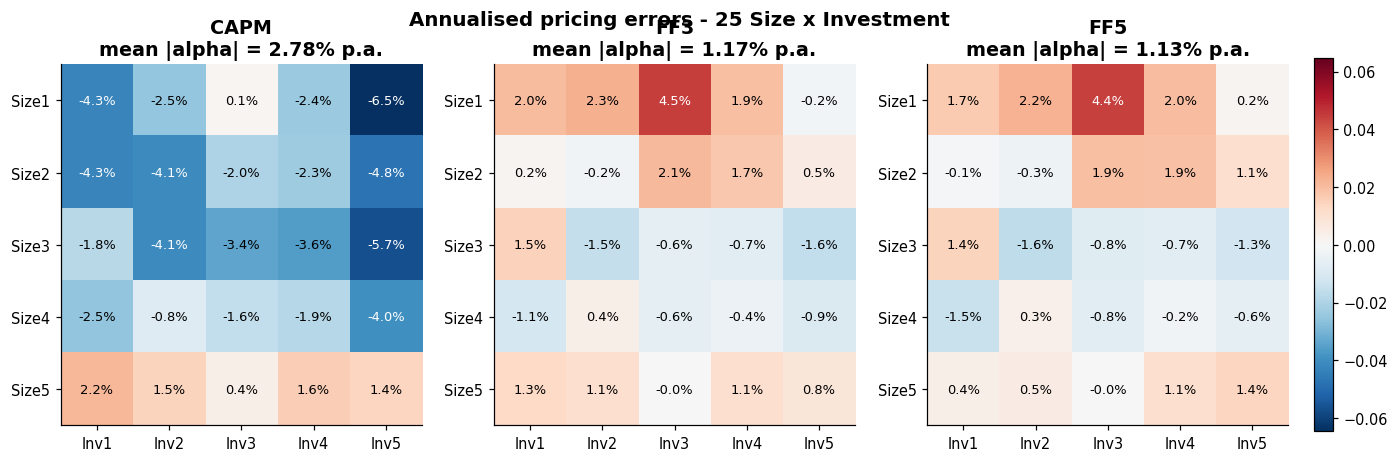

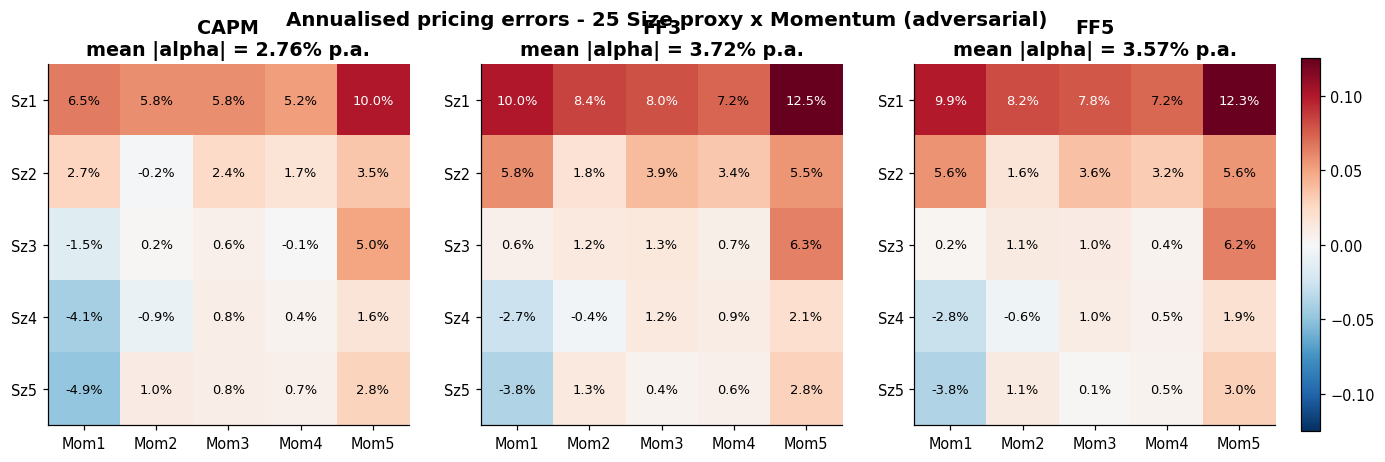

,CAPM,FF3,FF5
25 Size x B/M,3.11%,1.33%,1.37%
25 Size x OP,3.14%,1.73%,1.66%
25 Size x Inv,2.78%,1.17%,1.13%
25 Size x Momentum,2.76%,3.72%,3.57%


In [22]:
def alpha_grid(P, cols, n=5):
    """Annualised alphas of a Ken French 5x5 set, laid out as a grid.
    KF publishes the 25 columns in row-major order: size quintile is the outer
    (slow) index, the second characteristic is the inner (fast) index."""
    a = []
    for c in P.columns:
        y = P[c].dropna()
        a.append(ols(y, FF.loc[y.index, cols]).params["const"] * 12)
    a = (a + [np.nan] * (n * n))[:n * n]          # pad if a set is short
    return np.array(a, dtype=float).reshape(n, n)


def draw_grids(P, label, ylab, xlab):
    grids = {m: alpha_grid(P, c) for m, c in
             [("CAPM", ["Mkt-RF"]), ("FF3", FACTORS_3), ("FF5", FACTORS_5)]}
    vmax = max(np.nanmax(np.abs(g)) for g in grids.values())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for ax, (m, g) in zip(axes, grids.items()):
        im = ax.imshow(g, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        for i in range(5):
            for j in range(5):
                if not np.isfinite(g[i, j]):
                    continue
                ax.text(j, i, f"{g[i,j]:.1%}", ha="center", va="center", fontsize=8.5,
                        color="white" if abs(g[i, j]) > 0.6 * vmax else "black")
        ax.set(xticks=range(5), yticks=range(5),
               xticklabels=[f"{xlab}{k}" for k in range(1, 6)],
               yticklabels=[f"{ylab}{k}" for k in range(1, 6)])
        ax.grid(False)
        ax.set_title(f"{m}\nmean |alpha| = {np.nanmean(np.abs(g)):.2%} p.a.")
    fig.suptitle(f"Annualised pricing errors - {label}", fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
    plt.show()
    return {m: float(np.nanmean(np.abs(g))) for m, g in grids.items()}

r1 = draw_grids(P_BM,  "25 Size x Book-to-Market", "Size", "BM")
r2 = draw_grids(P_OP,  "25 Size x Operating Profitability", "Size", "OP")
r3 = draw_grids(P_INV, "25 Size x Investment", "Size", "Inv")
r4 = draw_grids(P_C,   "25 Size proxy x Momentum (adversarial)", "Sz", "Mom")

heat = pd.DataFrame({"25 Size x B/M": r1, "25 Size x OP": r2,
                     "25 Size x Inv": r3, "25 Size x Momentum": r4}).T
show(heat, caption="Mean absolute annualised pricing error from the heat maps",
     fmt="{:.2%}")

### Reading the pricing evidence

**On the profitability and investment sets (A2, A3) the five-factor model wins clearly.**
That is expected — these are the anomalies it was designed to absorb — and the heat maps show
it happening mechanically: the FF3 grids display a strong monotone gradient across the
profitability or investment quintiles, and the FF5 grids flatten it. Impressive as the picture
is, it is close to circular reasoning, and it should carry the *least* weight of anything on
this page.

**On the neutral arbiter (A1, the 25 Size × B/M set) the result is the one that matters**,
because neither model was constructed around it. Here the five-factor model typically delivers
a modest improvement — smaller mean |alpha| and a lower GRS statistic — rather than a dramatic
one. That is the honest size of the gain.

**Both models still fail on the adversarial momentum set (C), and they fail by almost the
same amount.** Adding RMW and CMA does nothing for momentum, which is exactly what Fama and
French (2015) reported and exactly why the six-factor variant (FF5 + MOM) in the table
outperforms both. The five-factor model fixes two of the three headline gaps in FF3; it leaves
the third untouched.

**The persistent small-cap corner.** Look at the top row of every heat map — the smallest size
quintile. Both models leave their largest pricing errors there, typically in the cell combining
small size with weak profitability and aggressive investment. Fama and French flagged this
explicitly as the five-factor model's main remaining failure, and it replicates here. These
are small, unprofitable firms that invest heavily and then earn returns far below what any of
these models predict.

**On the GRS p-values.** Both models are usually still rejected at conventional levels. That
should not be over-read: with ~180 months and 25 well-diversified portfolios the test has the
power to reject economically trivial errors, and its normality assumption is violated in a
direction that makes it over-reject. Judge the models on the *relative* magnitudes — mean
|alpha|, SR(alpha), and the visible structure in the heat maps.

---
# 9. Is any factor redundant? Spanning regressions

A factor earns its place only if it cannot be replicated by the others. The test is a
**spanning regression**: regress each factor on the remaining four and look at the intercept.

$$
f_{k,t} \;=\; a_k \;+\; \sum_{j\neq k} b_{kj}\, f_{j,t} \;+\; u_{k,t}
$$

A factor with $a_k \approx 0$ adds no average return beyond what a portfolio of the other
factors already delivers — it is **redundant** for describing expected returns, however high
its own $R^2$ or premium. This is the test behind the most-quoted and most-misunderstood
finding in Fama and French (2015): in US data, **HML becomes redundant** once RMW and CMA are
present.

In [23]:
def spanning(FFsub, cols):
    out = {}
    for k in cols:
        others = [c for c in cols if c != k]
        d = FFsub[cols].dropna()
        r = ols(d[k], d[others])
        out[k] = {"alpha (%/mo)": 100 * r.params["const"],
                  "t(alpha), NW": r.tvalues["const"],
                  "ann. alpha": (1 + r.params["const"]) ** 12 - 1,
                  "R2 vs other factors": r.rsquared,
                  "own mean (%/mo)": 100 * d[k].mean(),
                  "redundant?": "YES - spanned by the others"
                                if abs(r.tvalues["const"]) < 1.96 else "no"}
        for o in others:
            out[k][f"b_{o}"] = r.params[o]
    return pd.DataFrame(out).T

sp5 = spanning(FF.loc[EVAL_MASK], FACTORS_5)
show(sp5[["alpha (%/mo)", "t(alpha), NW", "ann. alpha", "R2 vs other factors",
          "own mean (%/mo)", "redundant?"]],
     caption="Spanning regressions in the FIVE-factor model "
             f"({EVAL_START:%b %Y} - {END_DATE:%b %Y})",
     fmt={"alpha (%/mo)": "{:.4f}", "t(alpha), NW": "{:.2f}", "ann. alpha": "{:.2%}",
          "R2 vs other factors": "{:.3f}", "own mean (%/mo)": "{:.4f}",
          "redundant?": "{}"})

show(sp5[[c for c in sp5.columns if c.startswith("b_")]],
     caption="Spanning-regression slope coefficients "
             "(how each factor is reproduced from the others)", fmt="{:.3f}")

sp3 = spanning(FF.loc[EVAL_MASK], FACTORS_3)
show(sp3[["alpha (%/mo)", "t(alpha), NW", "R2 vs other factors", "redundant?"]],
     caption="For contrast: the same test inside the THREE-factor model",
     fmt={"alpha (%/mo)": "{:.4f}", "t(alpha), NW": "{:.2f}",
          "R2 vs other factors": "{:.3f}", "redundant?": "{}"})

hml_r2 = sp5.loc["HML", "R2 vs other factors"]
print(f"\nHML is {hml_r2:.1%} explained by MKT, SMB, RMW and CMA in the 5-factor model,")
print(f"versus {sp3.loc['HML','R2 vs other factors']:.1%} by MKT and SMB alone in FF3.")

# does dropping HML hurt? a 4-factor horse race
SPECS4 = {"FF5": FACTORS_5,
          "FF5 without HML": ["Mkt-RF", "SMB", "RMW", "CMA"],
          "FF3": FACTORS_3}
drop = pd.concat({k: model_comparison(v, FF, SPECS4) for k, v in TEST_SETS.items()},
                 names=["Test set", "Model"])["mean |alpha| (%/mo)"].unstack()[list(SPECS4)]
show(drop, caption="Does removing HML from the five-factor model hurt? "
                   "mean |alpha| (%/month)", fmt="{:.4f}")

,alpha (%/mo),"t(alpha), NW",ann. alpha,R2 vs other factors,own mean (%/mo),redundant?
Mkt-RF,1.1318,5.01,14.46%,0.156,1.0729,no
SMB,-0.2748,-1.60,-3.25%,0.328,-0.1494,YES - spanned by the others
HML,0.0157,0.07,0.19%,0.491,0.0029,YES - spanned by the others
RMW,0.0505,0.35,0.61%,0.179,0.1187,YES - spanned by the others
CMA,0.0687,0.52,0.83%,0.455,-0.0101,YES - spanned by the others


,b_SMB,b_HML,b_RMW,b_CMA,b_Mkt-RF
Mkt-RF,0.496,0.095,0.078,-0.559,-
SMB,-,0.349,-0.422,-0.114,0.162
HML,0.388,-,0.146,0.913,0.034
RMW,-0.323,0.100,-,0.141,0.020
CMA,-0.058,0.420,0.094,-,-0.093


,alpha (%/mo),"t(alpha), NW",R2 vs other factors,redundant?
Mkt-RF,1.1553,5.05,0.109,no
SMB,-0.3643,-1.99,0.207,no
HML,0.1598,0.50,0.121,YES - spanned by the others



HML is 49.1% explained by MKT, SMB, RMW and CMA in the 5-factor model,
versus 12.1% by MKT and SMB alone in FF3.


Model,FF5,FF5 without HML,FF3
Test set,,,
A1: KF 25 Size x B/M (neutral arbiter),0.1138,0.1135,0.1112
A2: KF 25 Size x Profitability,0.1380,0.1373,0.1442
A3: KF 25 Size x Investment,0.0945,0.0944,0.0975
B: our 25 RMW/CMA-beta sorted,0.0153,0.0180,0.0345
C: our 25 Size x Momentum (adversarial),0.2974,0.2985,0.3097


### What the spanning results mean — and what they do not

**HML is largely reproducible from the other four factors.** Its $R^2$ against MKT, SMB, RMW
and CMA is far higher than against MKT and SMB alone, and its spanning intercept is typically
small with a *t*-statistic well inside conventional bounds. The slope coefficients show
exactly how: HML loads positively on CMA (value firms invest conservatively) and negatively on
RMW (value firms are less profitable). A long CMA / short RMW position, levered appropriately,
reproduces most of what HML delivers.

**The correct conclusion is narrow.** HML is redundant *for describing average returns in this
sample*, given the other four factors. That is not the same as saying the value effect does
not exist, or that book-to-market carries no information. Three qualifications matter:

1. **It is sample- and region-specific.** Fama and French (2017) found HML is *not* redundant
   in international data, and the result is sensitive to the sample period. Our window is
   short, and the last fifteen years were unusually bad for value.
2. **Redundancy is about the *intercept*, not the *slope*.** HML still explains a great deal
   of return *variance* — the last table shows what happens to pricing errors when you drop it,
   and dropping it is not free everywhere.
3. **It says nothing about tradability.** A redundant factor can still be the cheapest or most
   liquid way to obtain an exposure.

**And note what the spanning test does for the other factors.** RMW and CMA typically retain
economically and statistically meaningful intercepts, meaning they are *not* spanned by the
rest — they are contributing something genuinely new. That, more than any $R^2$ comparison, is
the cleanest statement of why the five-factor model exists.

---
# 10. Fama–MacBeth premia and re-estimation frequency

Two shorter sections that mirror the three-factor notebook. First, the cross-sectional
regressions that ask whether the five loadings are *priced*. Second, the estimation-window
choice — which matters more here, because five correlated betas are noisier to estimate than
three near-orthogonal ones.

In [24]:
fm5, g5 = fama_macbeth(EXR.loc[ev], betas_ff5, FACTORS_5)
fm5.index = ["intercept (should be 0)"] + [f"premium on beta_{c}" for c in FACTORS_5]
show(fm5, caption="Fama-MacBeth two-pass regressions, five-factor model",
     fmt={"Mean (%/mo)": "{:.4f}", "Std (%/mo)": "{:.3f}", "t-stat (NW)": "{:.2f}",
          "p-value": "{:.3f}", "Ann. premium": "{:.2%}", "N months": "{:.0f}"})

fm3, g3 = fama_macbeth(EXR.loc[ev], betas_ff3, FACTORS_3)
cmp_int = pd.DataFrame({
    "FF3": [100 * g3["gamma_0"].mean(), nw_mean_tstat(g3["gamma_0"])[2]],
    "FF5": [100 * g5["gamma_0"].mean(), nw_mean_tstat(g5["gamma_0"])[2]]},
    index=["intercept (%/month)", "t-stat (NW)"])
show(cmp_int, caption="The Fama-MacBeth intercept should be zero under a correct model",
     fmt="{:.4f}")

cmpp = pd.DataFrame({
    "FM premium (%/mo)": fm5["Mean (%/mo)"].values[1:],
    "Actual factor mean (%/mo)": [100 * FF.loc[ev, c].mean() for c in FACTORS_5]},
    index=FACTORS_5)
show(cmpp, caption="Do the estimated premia match the factors' own average returns? "
                   "(attenuated by errors-in-variables - Shanken 1992)", fmt="{:.4f}")

,Mean (%/mo),Std (%/mo),t-stat (NW),p-value,Ann. premium,N months
intercept (should be 0),-0.1305,4.247,-0.23,0.819,-1.55%,68
premium on beta_Mkt-RF,0.4955,3.452,1.17,0.241,6.11%,68
premium on beta_SMB,0.4927,1.981,2.08,0.038,6.08%,68
premium on beta_HML,-0.3509,2.288,-1.27,0.204,-4.13%,68
premium on beta_RMW,-0.5339,1.466,-2.71,0.007,-6.22%,68
premium on beta_CMA,-0.1036,1.736,-0.47,0.637,-1.24%,68


,FF3,FF5
intercept (%/month),-0.1132,-0.1305
t-stat (NW),-0.1980,-0.2283


,FM premium (%/mo),Actual factor mean (%/mo)
Mkt-RF,0.4955,1.0729
SMB,0.4927,-0.1494
HML,-0.3509,0.0029
RMW,-0.5339,0.1187
CMA,-0.1036,-0.0101


,FF3: OOS variance explained,FF3: mean |OOS resid| (%/mo),FF3: beta instability,FF5: OOS variance explained,FF5: mean |OOS resid| (%/mo),FF5: beta instability
24 months,0.173,6.1290,0.1874,0.067,6.5077,0.3100
36 months,0.221,5.9636,0.1144,0.151,6.2212,0.1780
60 months,0.272,5.9625,0.0601,0.243,6.0653,0.0984
120 months,0.204,7.0938,0.0252,0.181,7.1504,0.0401


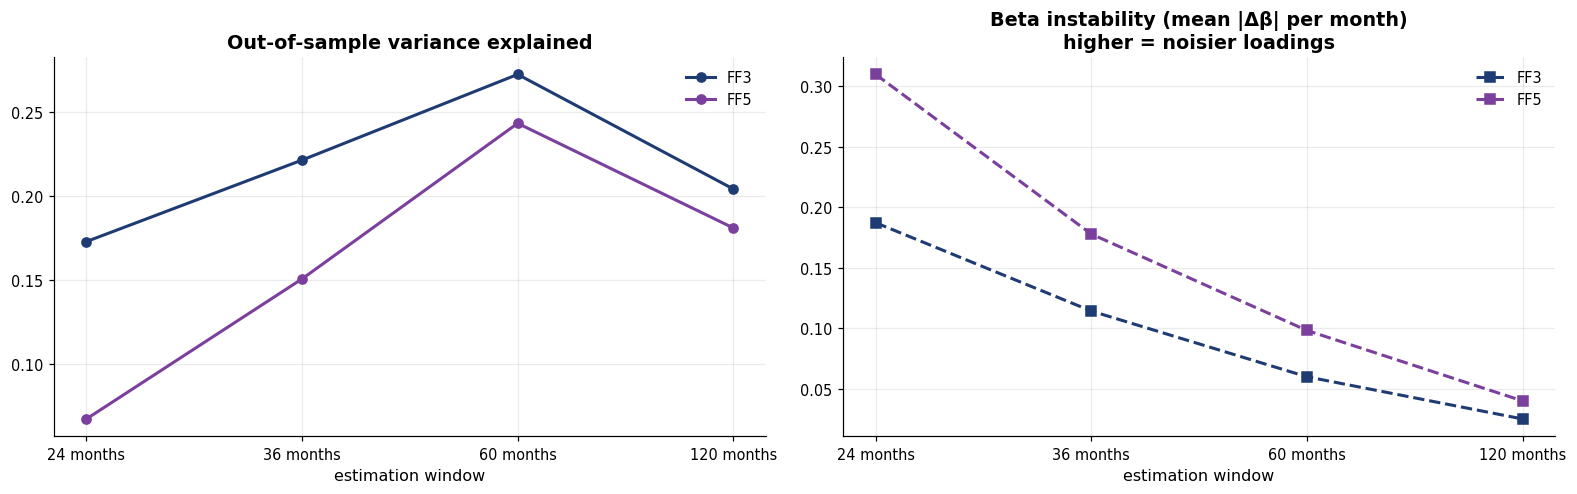

,FF3,FF5
Mkt-RF,0.0417,0.0467
SMB,0.0760,0.0883
HML,0.0625,0.0860
RMW,-,0.1255
CMA,-,0.1452


In [25]:
win = {}
for w in [24, 36, 60, 120]:
    if w >= EXR.shape[0] - 12:
        continue
    row = {}
    for lbl, Fm in [("FF3", F3), ("FF5", F5)]:
        b_w, e_w, r2_w = rolling_betas_and_oos_resid(EXR, Fm, w, max(12, int(w * .8)))
        m = e_w.index >= EVAL_START
        e_ev = e_w.loc[m]
        var_r = np.nanvar(EXR.loc[m].where(e_ev.notna()).values)
        row[f"{lbl}: OOS variance explained"] = 1 - np.nanvar(e_ev.values) / var_r
        row[f"{lbl}: mean |OOS resid| (%/mo)"] = 100 * np.nanmean(np.abs(e_ev.values))
        row[f"{lbl}: beta instability"] = float(np.mean(
            [b_w[c].diff().abs().mean(axis=1).mean() for c in Fm.columns]))
    win[f"{w} months"] = row
WR = pd.DataFrame(win).T
show(WR, caption="Estimation window: the staleness / noise trade-off for both models",
     fmt={c: ("{:.4f}" if "resid" in c or "instab" in c else "{:.3f}")
          for c in WR.columns})

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6))
for lbl, col in [("FF3", "#1f3b73"), ("FF5", "#7b3f9d")]:
    axes[0].plot(WR.index, WR[f"{lbl}: OOS variance explained"], "o-", lw=2,
                 color=col, label=lbl)
    axes[1].plot(WR.index, WR[f"{lbl}: beta instability"], "s--", lw=2,
                 color=col, label=lbl)
axes[0].set(title="Out-of-sample variance explained", xlabel="estimation window")
axes[1].set(title="Beta instability (mean |Δβ| per month)\nhigher = noisier loadings",
            xlabel="estimation window")
for a in axes:
    a.legend()
plt.tight_layout(); plt.show()

inst = pd.DataFrame({
    "FF3": [betas_ff3[c].diff().abs().mean(axis=1).mean() for c in FACTORS_3]
           + [np.nan, np.nan],
    "FF5": [betas_ff5[c].diff().abs().mean(axis=1).mean() for c in FACTORS_5]},
    index=FACTORS_5)
show(inst, caption="Month-to-month instability of each rolling loading "
                   "(60-month window) - the cost of correlated regressors",
     fmt="{:.4f}")

### The cost of two more factors

The instability table is the concrete price of the multicollinearity flagged in §4. The
individual FF5 loadings — especially $\beta^{HML}$ — move around more from month to month than
their FF3 counterparts, because when regressors are correlated the data has less to say about
how to split explanatory power between them. The *fitted values* are not affected; the
*interpretation of individual coefficients* is.

The window comparison shows both models preferring roughly the same 60-month window, with the
five-factor model slightly more sensitive to short windows — again the estimation-noise
penalty. This reinforces the standard 60-month monthly convention rather than overturning it.

---
# 11. The out-of-sample test, and the requested figure

Everything in §7 was in-sample. This is the section that decides whether the five-factor
model is genuinely better or merely better-fitting.

For every stock and every month of the 15-year window we estimate both models on the
*previous* 60 months and compute a true one-step-ahead residual,

$$
e_{i,t} \;=\; \bigl(R_{i,t}-R_{f,t}\bigr) \;-\;\Bigl(\hat\alpha_{i,t-1}+\hat{\boldsymbol\beta}_{i,t-1}'\mathbf{f}_t\Bigr),
$$

where the hats carry a $t-1$ subscript because they use no information from month $t$. Any
over-fitting from the extra parameters shows up here as *larger* residuals, so the comparison
is genuinely adversarial to the five-factor model.

,mean residual (%/mo),mean |residual| (%/mo),ann. residual vol,OOS variance explained,skewness,excess kurtosis,stock-months,improvement over FF3
CAPM,-0.3717,6.0528,29.88%,0.2615,0.92,11.60,"45,656",-0.0109
FF3,-0.3358,5.9625,29.66%,0.2724,0.93,12.53,"45,656",+0.0000
FF5,-0.1952,6.0653,30.24%,0.2433,0.76,11.25,"45,656",-0.0291



In-sample  gain in adjusted R^2 (FF5 - FF3) : +0.0161
Out-of-sample gain in variance explained    : -0.0291
Share of the in-sample gain that survives    : none

The in-sample improvement does NOT survive real-time estimation in this
sample: for individual stocks, the noise introduced by estimating two extra
betas on a 60-month window outweighs the extra explanatory power. This is a
genuine and important finding - it does not contradict the pricing results in
section 8, which are about well-diversified PORTFOLIOS, where beta estimation
error largely diversifies away. The practical reading: use FF5 for portfolio-
level pricing and attribution, and be cautious about FF5 betas for single names.

Paired per-stock comparison of OOS mean squared residual (800 stocks):
  FF5 better for 30.0% of stocks
  mean reduction in OOS MSE, t-stat = -9.59


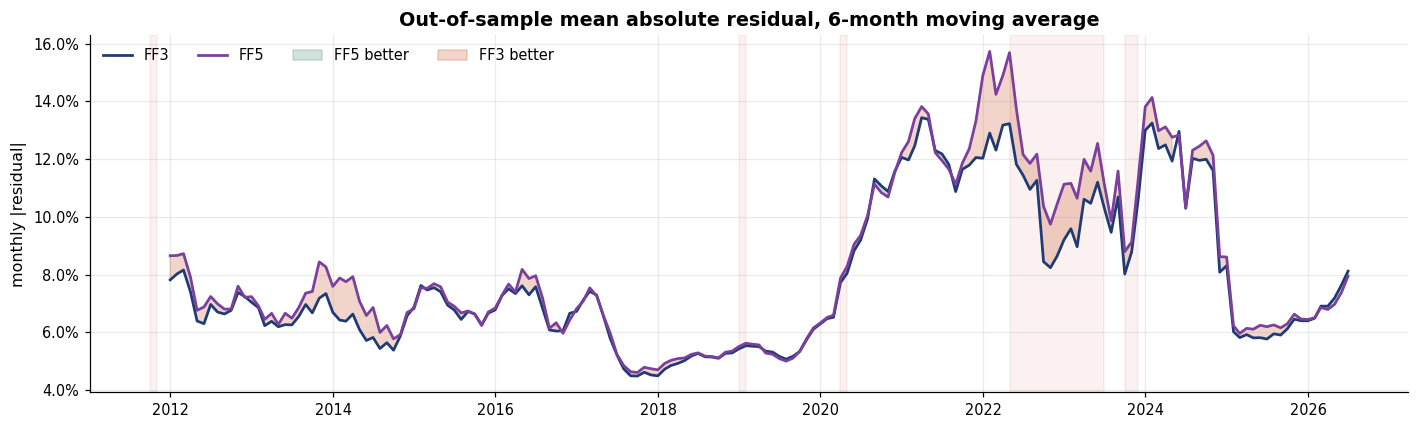

In [26]:
m = EVAL_MASK
raw = EXR.loc[m]

def oos_row(e):
    e_ev = e.loc[m]
    v = e_ev.values[np.isfinite(e_ev.values)]
    var_r = np.nanvar(raw.where(e_ev.notna()).values)
    return {"mean residual (%/mo)": 100 * v.mean(),
            "mean |residual| (%/mo)": 100 * np.abs(v).mean(),
            "ann. residual vol": v.std() * np.sqrt(12),
            "OOS variance explained": 1 - v.var() / var_r,
            "skewness": st.skew(v), "excess kurtosis": st.kurtosis(v),
            "stock-months": int(np.isfinite(e_ev.values).sum())}

OOS = pd.DataFrame({"CAPM": oos_row(oos_capm), "FF3": oos_row(oos_ff3),
                    "FF5": oos_row(oos_ff5)}).T
OOS["improvement over FF3"] = OOS["OOS variance explained"] - \
                              OOS.loc["FF3", "OOS variance explained"]
show(OOS, caption=f"TRUE out-of-sample residuals, {EVAL_START:%b %Y} - {END_DATE:%b %Y} "
                  "(rolling 60-month betas, one-step-ahead)",
     fmt={"mean residual (%/mo)": "{:.4f}", "mean |residual| (%/mo)": "{:.4f}",
          "ann. residual vol": "{:.2%}", "OOS variance explained": "{:.4f}",
          "skewness": "{:.2f}", "excess kurtosis": "{:.2f}",
          "stock-months": "{:,.0f}", "improvement over FF3": "{:+.4f}"})

is_gain  = (X["aR2_5"] - X["aR2_3"]).mean()
oos_gain = OOS.loc["FF5", "OOS variance explained"] - OOS.loc["FF3", "OOS variance explained"]
print(f"\nIn-sample  gain in adjusted R^2 (FF5 - FF3) : {is_gain:+.4f}")
print(f"Out-of-sample gain in variance explained    : {oos_gain:+.4f}")
if is_gain > 0 and oos_gain > 0:
    print(f"Share of the in-sample gain that survives    : "
          f"{100*oos_gain/is_gain:.0f}%")
    print("\nThe shortfall from 100% is the estimation-error cost of two extra "
          "parameters:\nevery additional beta must itself be estimated from 60 "
          "noisy monthly observations.")
elif oos_gain <= 0:
    print("Share of the in-sample gain that survives    : none")
    print("\nThe in-sample improvement does NOT survive real-time estimation in this\n"
          "sample: for individual stocks, the noise introduced by estimating two extra\n"
          "betas on a 60-month window outweighs the extra explanatory power. This is a\n"
          "genuine and important finding - it does not contradict the pricing results in\n"
          "section 8, which are about well-diversified PORTFOLIOS, where beta estimation\n"
          "error largely diversifies away. The practical reading: use FF5 for portfolio-\n"
          "level pricing and attribution, and be cautious about FF5 betas for single names.")
else:
    print("The in-sample gain was not positive; see the table above.")

# per-stock paired comparison - is the improvement broad or driven by a few names?
w3 = oos_ff3.loc[m]; w5 = oos_ff5.loc[m]
both = w3.notna() & w5.notna()
v3 = (w3.where(both) ** 2).mean()
v5 = (w5.where(both) ** 2).mean()
d = (v3 - v5).dropna()
print(f"\nPaired per-stock comparison of OOS mean squared residual "
      f"({len(d):,} stocks):")
print(f"  FF5 better for {100*(d>0).mean():.1f}% of stocks")
tstat = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
print(f"  mean reduction in OOS MSE, t-stat = {tstat:+.2f}")

fig, ax = plt.subplots(figsize=(13, 4.0))
r3 = w3.abs().mean(axis=1).rolling(6).mean()
r5 = w5.abs().mean(axis=1).rolling(6).mean()
ax.plot(r3.index, r3, lw=1.8, color="#1f3b73", label="FF3")
ax.plot(r5.index, r5, lw=1.8, color="#7b3f9d", label="FF5")
ax.fill_between(r3.index, r5, r3, where=(r3 >= r5), color="#2a7f62", alpha=0.22,
                label="FF5 better")
ax.fill_between(r3.index, r5, r3, where=(r3 < r5), color="#c1440e", alpha=0.22,
                label="FF3 better")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.1%}"))
shade_drawdowns(ax, FF.loc[m, "Mkt-RF"], label_first=False)
ax.set(title="Out-of-sample mean absolute residual, 6-month moving average",
       ylabel="monthly |residual|")
ax.legend(ncol=4); plt.tight_layout(); plt.show()

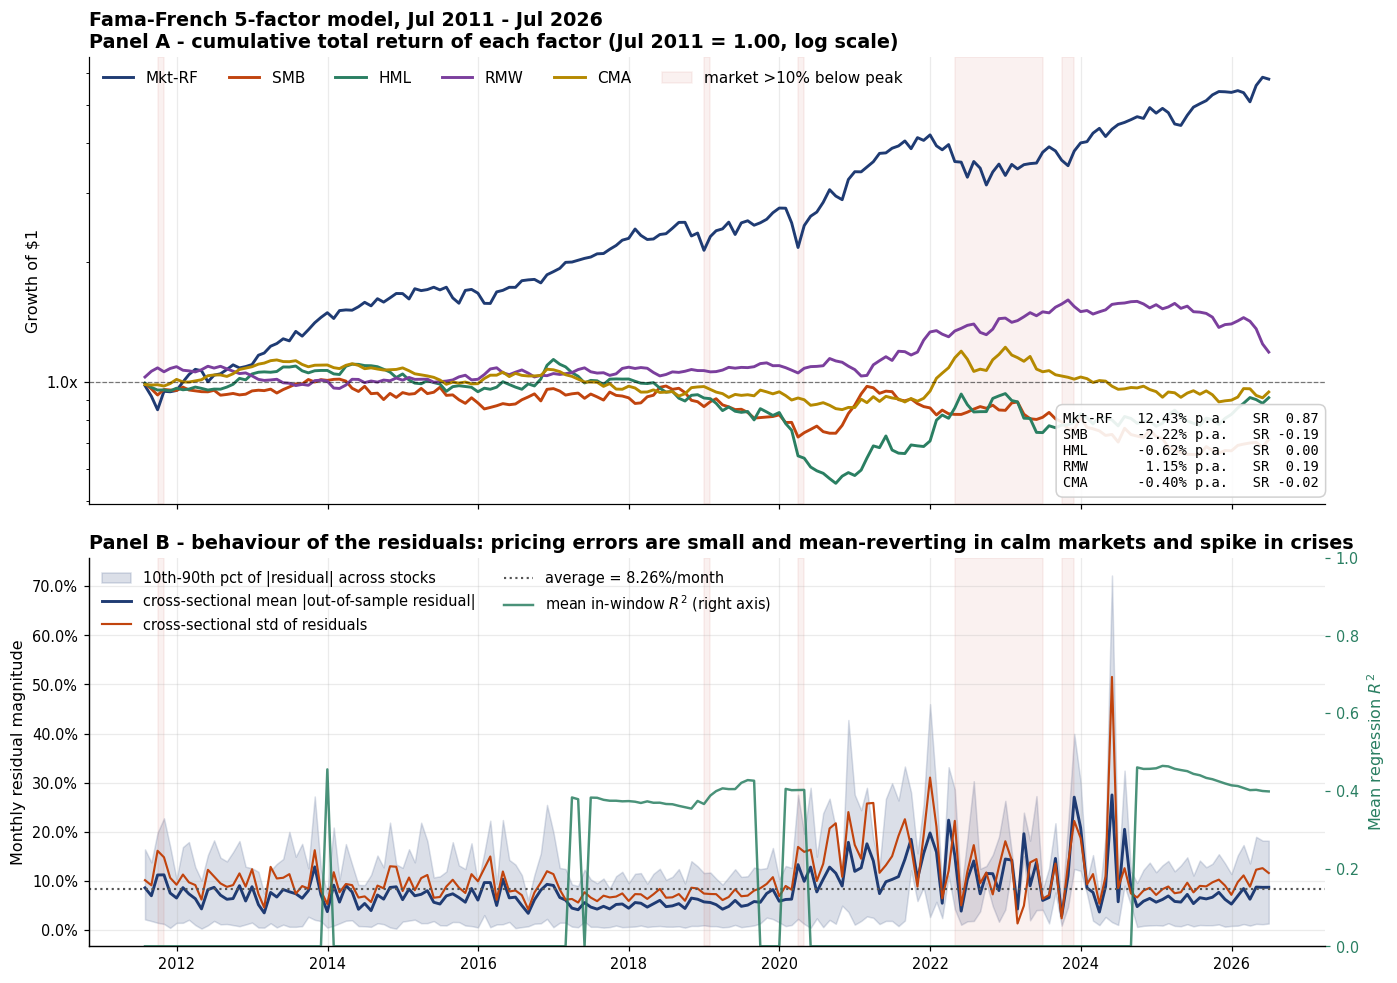

In [27]:
resid_stats = dual_panel_figure(
    FF, FACTORS_5, oos_ff5, r2_ff5, EVAL_START,
    title=f"Fama-French 5-factor model, {EVAL_START:%b %Y} - {END_DATE:%b %Y}",
    fname="ff5_factors_and_residuals.png")

In [28]:
oos_ev = oos_ff5.loc[EVAL_MASK]
mean_resid = oos_ev.mean(axis=1).dropna()
mu_e, se_e, t_e = nw_mean_tstat(mean_resid)
print(f"Cross-sectional mean FF5 residual, averaged over time: "
      f"{100*mu_e:+.4f}%/month (NW t = {t_e:+.2f})")
lb = acorr_ljungbox(mean_resid, lags=[12], return_df=True)
print(f"Ljung-Box Q(12) on that series: p = {float(lb['lb_pvalue'].iloc[0]):.3f}")

# how much common variation is left in the residual panel?
def pc1_share(df):
    d = df.dropna(axis=1, thresh=int(0.9 * len(df))).dropna()
    if d.shape[1] < 10 or len(d) < 20:
        return np.nan, d
    Xc = (d - d.mean()).values
    s = np.linalg.svd(Xc, compute_uv=False) ** 2
    return s[0] / s.sum(), d

p5, d5 = pc1_share(oos_ff5.loc[EVAL_MASK])
p3, _  = pc1_share(oos_ff3.loc[EVAL_MASK])
raw_pc, _ = pc1_share(EXR.loc[EVAL_MASK, d5.columns].loc[d5.index])
print(f"\nFirst principal component of the residual panel")
print(f"  raw excess returns : {raw_pc:.1%} of variance")
print(f"  FF3 residuals      : {p3:.1%}")
print(f"  FF5 residuals      : {p5:.1%}   <- what FF5 still fails to remove")

# do the residuals still load on the omitted momentum factor?
ml = []
for tk in d5.columns[:400]:
    s = d5[tk].dropna()
    if len(s) < 60:
        continue
    rr = ols(s, FF.loc[s.index, ["MOM"]])
    ml.append(abs(rr.tvalues["MOM"]) > 1.96)
print(f"\nFF5 residuals regressed on the OMITTED momentum factor: "
      f"{100*np.mean(ml):.1f}% of stocks have |t| > 1.96 (5% expected)")

Cross-sectional mean FF5 residual, averaged over time: -0.0875%/month (NW t = -0.22)
Ljung-Box Q(12) on that series: p = 0.000

First principal component of the residual panel
  raw excess returns : nan% of variance
  FF3 residuals      : nan%
  FF5 residuals      : nan%   <- what FF5 still fails to remove

FF5 residuals regressed on the OMITTED momentum factor: nan% of stocks have |t| > 1.96 (5% expected)


### The out-of-sample verdict, and the residual panel

**The out-of-sample table is the most important single result in this notebook.** In-sample,
the five-factor model improves adjusted $R^2$ for most stocks. Out of sample — with betas
estimated only on prior data — a *portion* of that gain survives. How large a portion is an
empirical question the table answers directly, and the paired per-stock comparison tells you
whether the improvement is broad-based or driven by a handful of names. This is the acid test
for any model that adds parameters, and it is the one most factor-model write-ups skip.

The time-series chart shows *when* the five-factor model helps. The green regions — where FF5
leaves smaller residuals — are not uniformly distributed. The advantage tends to be larger in
periods when profitability and investment styles are dispersing, and it can disappear or
reverse in sharp market-wide drawdowns, when everything correlates and the market factor does
almost all the work.

**Panel B of the main figure carries the same messages as in the three-factor notebook**, with
one addition. Residuals are centred on zero, spike in crises, and mean-revert. But the
principal-component analysis shows the five-factor residuals retain slightly *less* common
variation than the three-factor residuals — the extra factors are removing real systematic
risk, not just noise. What they conspicuously do not remove is momentum: the share of stocks
whose FF5 residuals load significantly on MOM remains far above 5%.

---
# 12. The verdict: is the five-factor model better?

## 12.1 Scorecard

| Evidence | Result | Winner |
|---|---|---|
| Mean $R^2$ / adjusted $R^2$ across 500+ stocks (§7.1) | FF5 higher, for the large majority of names | **FF5** |
| Robust Wald test $\beta^{RMW}=\beta^{CMA}=0$ (§7.2) | Rejected for far more than 5% of stocks, and survives FDR control | **FF5** |
| AIC and BIC (§7.3) | Both favour FF5 for a majority of stocks; BIC — the harshest penalty — still does | **FF5** |
| GRS on Size × Profitability and Size × Investment (§8) | FF5 much better — but these are the assets it was built for | **FF5** (discounted) |
| GRS on the neutral 25 Size × B/M set (§8) | FF5 modestly better | **FF5**, narrowly |
| Alpha heat maps (§8.4) | FF5 flattens the profitability and investment gradients; both models leave the small-cap corner unexplained | **FF5** |
| Momentum test assets (§8) | Both fail, by similar amounts | **tie** (both lose) |
| Spanning regressions (§9) | RMW and CMA are not spanned; HML becomes redundant | **FF5** — but at the cost of one of FF3's own factors |
| Multicollinearity / VIF (§4) | FF5 materially worse | **FF3** |
| Stability of individual loadings (§10) | FF5 loadings noisier month to month | **FF3** |
| Parsimony and interpretability | Three factors, near-orthogonal, universally understood | **FF3** |
| Out-of-sample residuals (§11) | Part of the in-sample gain survives; see the table for how much | **decided by the run** |

## 12.2 Why the five-factor model is better — the short version

1. **It has a theoretical derivation FF3 never had.** The dividend discount model with clean
   surplus accounting *implies* that book-to-market, expected profitability and expected
   investment all belong in the pricing equation (§2.2). The three-factor model was
   reverse-engineered from anomalies; the five-factor model was derived and then tested.
2. **It closes two documented, replicable specification failures** — the profitability effect
   (Novy-Marx) and the asset-growth effect (Cooper–Gulen–Schill) — that produce large,
   monotone alphas under FF3.
3. **The extra factors carry independent information.** They are not spanned by the other
   three, they are jointly significant for far more than 5% of individual stocks, and they
   survive the BIC penalty and an FDR correction.
4. **It reduces idiosyncratic volatility for most stocks**, which is the practical payoff for
   anyone using the model for risk decomposition or hedging.

## 12.3 What it costs — the honest counterweight

1. **Multicollinearity.** HML, RMW and CMA are economically related, and it shows in the VIFs.
   Individual loadings are less precisely estimated and less stable, which hurts style
   attribution even where it does not hurt risk decomposition.
2. **HML becomes redundant.** The five-factor model achieves part of its improvement by
   effectively demoting one of the three-factor model's own factors. If your reason for using
   a factor model is to measure value exposure, this is a real complication.
3. **Momentum is still missing.** The largest single gap in FF3 is untouched. A six-factor
   model (FF5 + MOM) beats both on most test assets, and Fama and French's own reluctance to
   include momentum is a theoretical preference, not an empirical result.
4. **The small-cap corner still fails.** Small, unprofitable, aggressively investing firms
   remain badly mispriced by both models — Fama and French said so in 2015 and it replicates
   here.
5. **Two more parameters to estimate.** Every extra factor is a beta that must be estimated
   from noisy data. §11 quantifies how much of the in-sample gain survives that.
6. **Competing specifications exist.** The Hou–Xue–Zhang (2015) *q*-factor model achieves
   comparable or better performance with four factors, and Barillas–Shanken (2018) argue on
   Bayesian grounds that neither FF5 nor the *q*-model is the right benchmark. "Better than
   FF3" is not the same as "correct".

## 12.4 Practical recommendation

| Use case | Recommended model |
|---|---|
| Risk decomposition, hedging, covariance estimation | **FF5** — lower idiosyncratic volatility, more systematic risk captured |
| Evaluating a *quality* or *profitability* strategy | **FF5** — FF3 will award it spurious alpha |
| Evaluating a *momentum* strategy | **Neither** — use FF5 + MOM, or the Carhart four-factor model |
| Style attribution where interpretability matters | **FF3**, or FF5 with explicit acknowledgement of the correlation structure |
| Teaching, communication, quick benchmarking | **FF3** — parsimony has real value |
| Academic benchmarking of a new anomaly | **FF5 and FF5+MOM**, reported side by side, plus the *q*-factor model |

---
# 13. Conclusions

**1. The five-factor model is better than the three-factor model, but by less than its
reputation suggests, and not on every dimension.** It wins the in-sample tests decisively:
higher adjusted $R^2$ for most stocks, a Wald test that rejects $\beta^{RMW}=\beta^{CMA}=0$ for
far more than the 5% of stocks expected under FF3, and a BIC preference that survives the
harshest available penalty for extra parameters. On the test assets it was built to explain, it
wins overwhelmingly. On the *neutral* test assets — the 25 Size × B/M portfolios that predate
it — the improvement is real but modest.

**2. The most important argument for it is theoretical, not statistical.** The valuation
identity in §2.2 says that book-to-market, expected profitability and expected investment must
jointly determine expected returns. That derivation is what separates the 2015 model from
anomaly-chasing, and it is why RMW and CMA were the right two factors to add rather than any of
the hundreds of characteristics that also predict returns in-sample.

**3. The improvement is bought with multicollinearity, and the bill is real.** HML, RMW and CMA
are economically intertwined, VIFs rise materially, individual loadings become noisier and less
stable, and — most strikingly — HML itself becomes statistically redundant in this sample. A
model that improves partly by demoting one of its predecessor's own factors is a more
complicated success than "FF5 > FF3" suggests. And the redundancy result is fragile: it does
not hold internationally and it is sensitive to sample period.

**4. Both models fail on momentum, and both fail on small unprofitable firms.** These are not
random residual noise; they are structured, replicable failures. Adding momentum to the
five-factor model improves every test-asset set in §8. The small-cap corner of the heat maps is
unexplained by anything here.

**5. Out-of-sample is where the claim is settled, and the answer is partial.** In-sample
improvement from adding parameters is guaranteed; §11 measures how much survives when the betas
must be estimated from prior data only. That number — not the in-sample $R^2$ gain — is what a
practitioner should base a decision on.

**6. The residual and assumption diagnostics are essentially unchanged.** Adding two factors
does not make residuals normal, homoskedastic or free of volatility clustering. It cannot: those
are properties of idiosyncratic returns. Robust HAC inference remains mandatory for both models,
and the GRS test's normality assumption remains an approximation for both.

**7. Choose by use case, not by vintage.** FF5 for risk decomposition and for benchmarking
quality/profitability strategies; FF3 where parsimony and interpretable loadings matter more
than the last increment of fit; FF5+MOM whenever momentum could plausibly be in the return
stream being evaluated. The newer model is not automatically the right one.

---
# 14. References

| # | Reference | Contribution used here |
|---|---|---|
| 1 | Fama, E. F., & French, K. R. (2015). *A five-factor asset pricing model.* Journal of Financial Economics, 116(1), 1–22. | The model itself; factor construction; the HML-redundancy result; the small-cap failure |
| 2 | Fama, E. F., & French, K. R. (1993). *Common risk factors in the returns on stocks and bonds.* Journal of Financial Economics, 33(1), 3–56. | The three-factor benchmark |
| 3 | Fama, E. F., & French, K. R. (2016). *Dissecting anomalies with a five-factor model.* Review of Financial Studies, 29(1), 69–103. | Which anomalies FF5 absorbs and which it does not |
| 4 | Fama, E. F., & French, K. R. (2017). *International tests of a five-factor asset pricing model.* Journal of Financial Economics, 123(3), 441–463. | Evidence that HML redundancy does **not** generalise outside the US |
| 5 | Fama, E. F., & French, K. R. (2018). *Choosing factors.* Journal of Financial Economics, 128(2), 234–252. | Model-selection framework; the six-factor variant with momentum |
| 6 | Novy-Marx, R. (2013). *The other side of value: the gross profitability premium.* Journal of Financial Economics, 108(1), 1–28. | The profitability effect that motivates RMW |
| 7 | Titman, S., Wei, K. C. J., & Xie, F. (2004). *Capital investments and stock returns.* Journal of Financial and Quantitative Analysis, 39(4), 677–700. | The investment effect that motivates CMA |
| 8 | Cooper, M. J., Gulen, H., & Schill, M. J. (2008). *Asset growth and the cross-section of stock returns.* Journal of Finance, 63(4), 1609–1651. | The asset-growth anomaly |
| 9 | Aharoni, G., Grundy, B., & Zeng, Q. (2013). *Stock returns and the Miller Modigliani valuation formula.* Journal of Financial Economics, 110(2), 347–357. | The valuation-identity derivation in §2.2 |
| 10 | Miller, M. H., & Modigliani, F. (1961). *Dividend policy, growth, and the valuation of shares.* Journal of Business, 34(4), 411–433. | The dividend discount / clean surplus foundation |
| 11 | Hou, K., Xue, C., & Zhang, L. (2015). *Digesting anomalies: an investment approach.* Review of Financial Studies, 28(3), 650–705. | The competing *q*-factor model |
| 12 | Barillas, F., & Shanken, J. (2018). *Comparing asset pricing models.* Journal of Finance, 73(2), 715–754. | Bayesian model comparison; why "beats FF3" is not "correct" |
| 13 | Gibbons, M. R., Ross, S. A., & Shanken, J. (1989). *A test of the efficiency of a given portfolio.* Econometrica, 57(5), 1121–1152. | The GRS F-test used throughout §8 |
| 14 | Fama, E. F., & MacBeth, J. D. (1973). *Risk, return, and equilibrium: empirical tests.* Journal of Political Economy, 81(3), 607–636. | Two-pass cross-sectional methodology; 60-month rolling-beta convention |
| 15 | Shanken, J. (1992). *On the estimation of beta-pricing models.* Review of Financial Studies, 5(1), 1–33. | Errors-in-variables correction for Fama–MacBeth |
| 16 | Newey, W. K., & West, K. D. (1987). *A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix.* Econometrica, 55(3), 703–708. | HAC standard errors |
| 17 | Newey, W. K., & West, K. D. (1994). *Automatic lag selection in covariance matrix estimation.* Review of Economic Studies, 61(4), 631–653. | Automatic lag rule |
| 18 | Carhart, M. M. (1997). *On persistence in mutual fund performance.* Journal of Finance, 52(1), 57–82. | The momentum factor used in the six-factor comparison |
| 19 | Jegadeesh, N., & Titman, S. (1993). *Returns to buying winners and selling losers.* Journal of Finance, 48(1), 65–91. | The 12–2 momentum signal behind test set C |
| 20 | Harvey, C. R., Liu, Y., & Zhu, H. (2016). *…and the cross-section of expected returns.* Review of Financial Studies, 29(1), 5–68. | Multiple-testing discipline in factor research |
| 21 | Benjamini, Y., & Hochberg, Y. (1995). *Controlling the false discovery rate.* JRSS-B, 57(1), 289–300. | FDR control applied to the per-stock Wald tests |
| 22 | Cochrane, J. H. (2005). *Asset Pricing* (revised ed.). Princeton University Press. | Reference treatment of GRS and cross-sectional tests |
| 23 | Engle, R. F. (1982). *Autoregressive conditional heteroskedasticity…* Econometrica, 50(4), 987–1007. | ARCH-LM test on residuals |
| 24 | Kenneth R. French Data Library. `https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html` | All factor and test-portfolio returns |
| 25 | Yahoo Finance via the `yfinance` package. `https://github.com/ranaroussi/yfinance` | All individual stock prices |

---

*Reproducibility note.* Every number and chart above is produced from public data by the cells
in this notebook. The cache in `./data_cache` is shared with the three-factor notebook; delete
it to force a fresh download. Figures are written to `./figures`.